In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

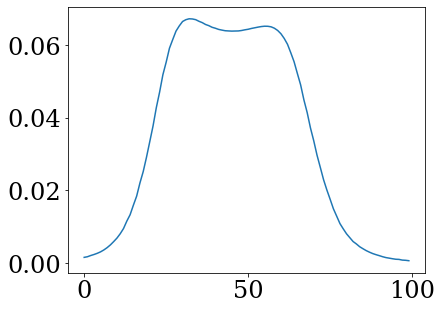

In [3]:
plt.plot(get_filter("../data/HST_NICMOS1.F108N.dat")[:,1][40:140])

In [4]:
wid = 64
oversample = 4

nwavels = 3
npoly=1

n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = "../data/MAST_2026-02-02T23_18_00.739Z/HST/"

files_f190N = """
n8o101a1q_cal.fits
n8o101a2q_cal.fits
n8o101a3q_cal.fits
""".split()[:1]


files_f108N = """
n8o101adq_cal.fits
n8o101atq_cal.fits
n8o101b9q_cal.fits
""".split()[:1]


files_f164N = """
n8o101a8q_cal.fits
n8o101a9q_cal.fits
n8o101aaq_cal.fits
""".split()[:1]

exposures_binary_f108N = [exposure_from_file(ddir + file, BinaryFit(spectrum_basis, "F108N"), crop=wid) for file in files_f108N]
exposures_binary_f190N = [exposure_from_file(ddir + file, BinaryFit(spectrum_basis, "F190N"), crop=wid) for file in files_f190N]
exposures_binary_f164N = [exposure_from_file(ddir + file, BinaryFit(spectrum_basis, "F164N"), crop=wid) for file in files_f164N]

exposures_binary = exposures_binary_f190N+exposures_binary_f108N+exposures_binary_f164N

exposures_single_f108N = [exposure_from_file(ddir + file, SinglePointFit(spectrum_basis, "F108N"), crop=wid) for file in files_f108N]
exposures_single_f190N = [exposure_from_file(ddir + file, SinglePointFit(spectrum_basis, "F190N"), crop=wid) for file in files_f190N]
exposures_single_f164N = [exposure_from_file(ddir + file, SinglePointFit(spectrum_basis, "F164N"), crop=wid) for file in files_f164N]

exposures_single = exposures_single_f190N+exposures_single_f108N+exposures_single_f164N

W0721 13:44:44.897497 24195533 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Version 4.4.1
115 76


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


Version 4.4.1
105 76
Version 4.4.1
105 76
Version 4.4.1
115 76
Version 4.4.1
105 76
Version 4.4.1
105 76


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This

In [5]:
for e in exposures_binary:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)


53049.23564742
GL164
F190N
31.95922
53049.24057796
GL164
F108N
47.94641
53049.23863351
GL164
F164N
23.96563


In [6]:
params = {
    "positions": {},
    "spectrum": {},

    "aberrations": {},


    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,
    "scale": 0.043142,

    "softening": 10.,
    "bias": {},
    "jitter": {},

    "defocus": {},
    "fnumber": 78.75,
    "quadrature": {},
}


for idx, exp in enumerate(exposures_binary):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "primary_spectrum")] = np.zeros(npoly).at[0].set((np.nansum(exp.data)/nwavels)/0.2)

    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.,8.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.0

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))


params_single = ModelParams(params)

In [7]:
params = {
    "positions": {},
    "primary_spectrum": {},
    "secondary_spectrum": {},

    "aberrations": {},

    "separation": 2.,
    "position_angle": 110., #-180.,


    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,
    "scale": 0.043142,

    "softening": 10.,
    "bias": {},
    "jitter": {},

    "defocus": {},
    "fnumber": 78.75,
    "quadrature": {},
}


for idx, exp in enumerate(exposures_binary):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["primary_spectrum"][exp.fit.get_key(exp, "primary_spectrum")] = np.zeros(npoly).at[0].set((np.nansum(exp.data)/nwavels))*0.85/0.2
    params["secondary_spectrum"][exp.fit.get_key(exp, "secondary_spectrum")] = np.array([(np.nansum(exp.data)/nwavels)/(6.3)])/0.2 if exp.filter == "F108N" else np.array([(np.nansum(exp.data)/nwavels)/(6.9)])/0.2
    
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)#+1.

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.,8.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.0

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample

    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.

params["aberrations"] = {'n8o101a1q': np.array([34.38720418,  0.93498722, -2.49119371,  1.52216231,  2.15430958,
         -7.1407251 , 11.74372184,  6.16881233, 14.31439312,  4.97982539,
         -3.29576677,  5.98738654, -0.87356344,  3.1029854 ,  2.76069699,
         -0.16228845,  2.46898271, -9.69903282,  3.43226586,  3.04655473]),
  'n8o101a8q': np.array([ 29.48255517,  -2.92326919,  -1.86042199,   2.32448629,
           1.30417821,  -7.17005065,  15.35279515,   4.29904691,
           6.06042797,   0.12023449,  -8.38217988,   6.2900379 ,
           2.49317595,   3.44838842,   1.19602504,  -1.90331527,
           1.69972148, -14.52918499,   3.50793853,   3.37671429]),
  'n8o101adq': np.array([ 16.44956167,   0.79714579,  -3.02727   ,   0.32613312,
           0.29145641,  -3.63712609,  10.21143441,   4.2609724 ,
           7.76831855,  -0.55764935,  -5.92589598,   6.27140904,
          -2.68395112,   2.88720105,  -1.2835726 ,  -3.03498673,
          -4.9529721 , -12.47289035,  -2.40090685,   3.59736151])}


model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params_binary = ModelParams(params)

9.966978428933926
10.628197870649984
12.270319285582286


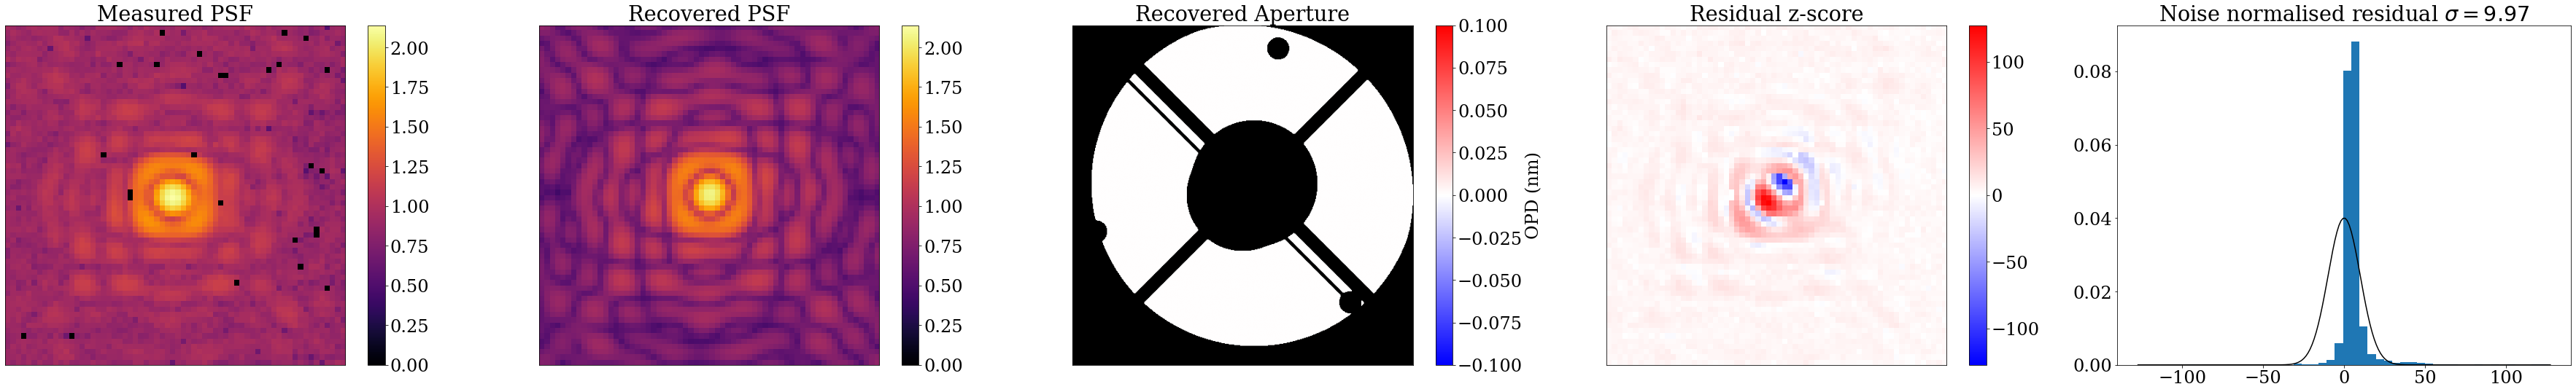

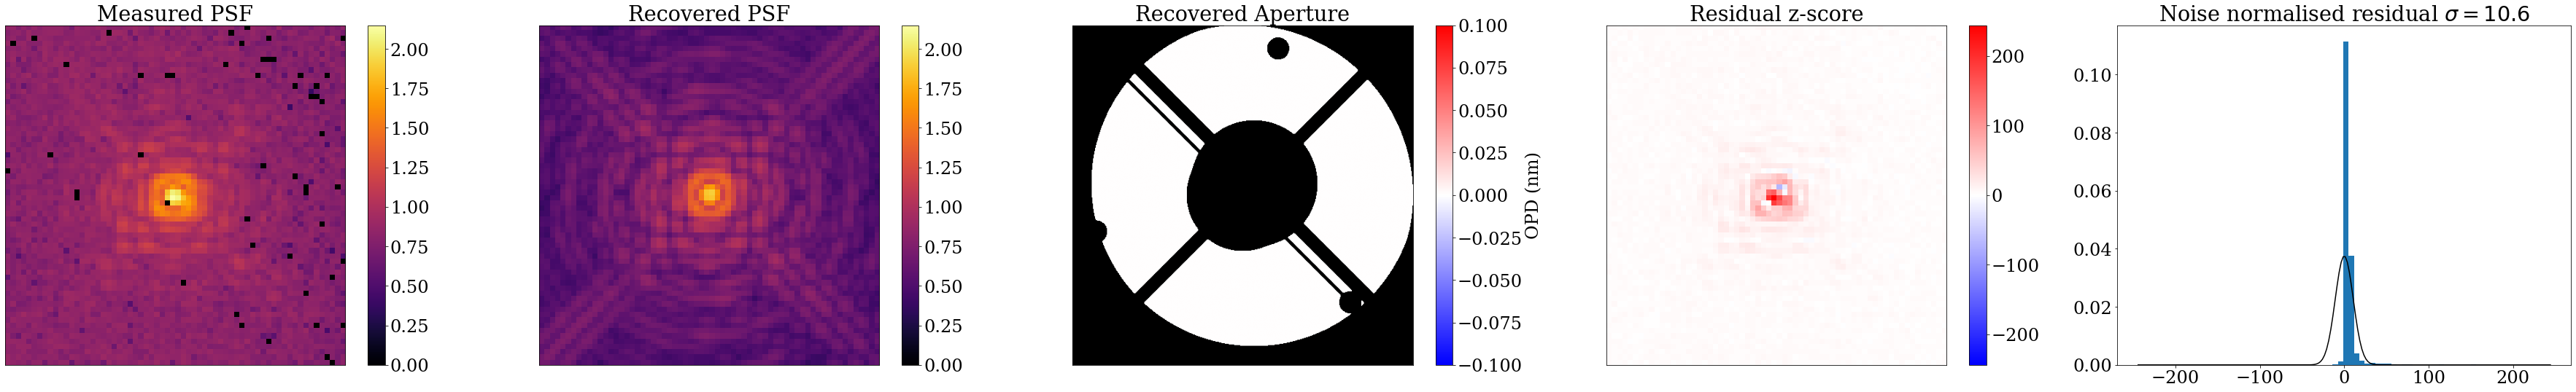

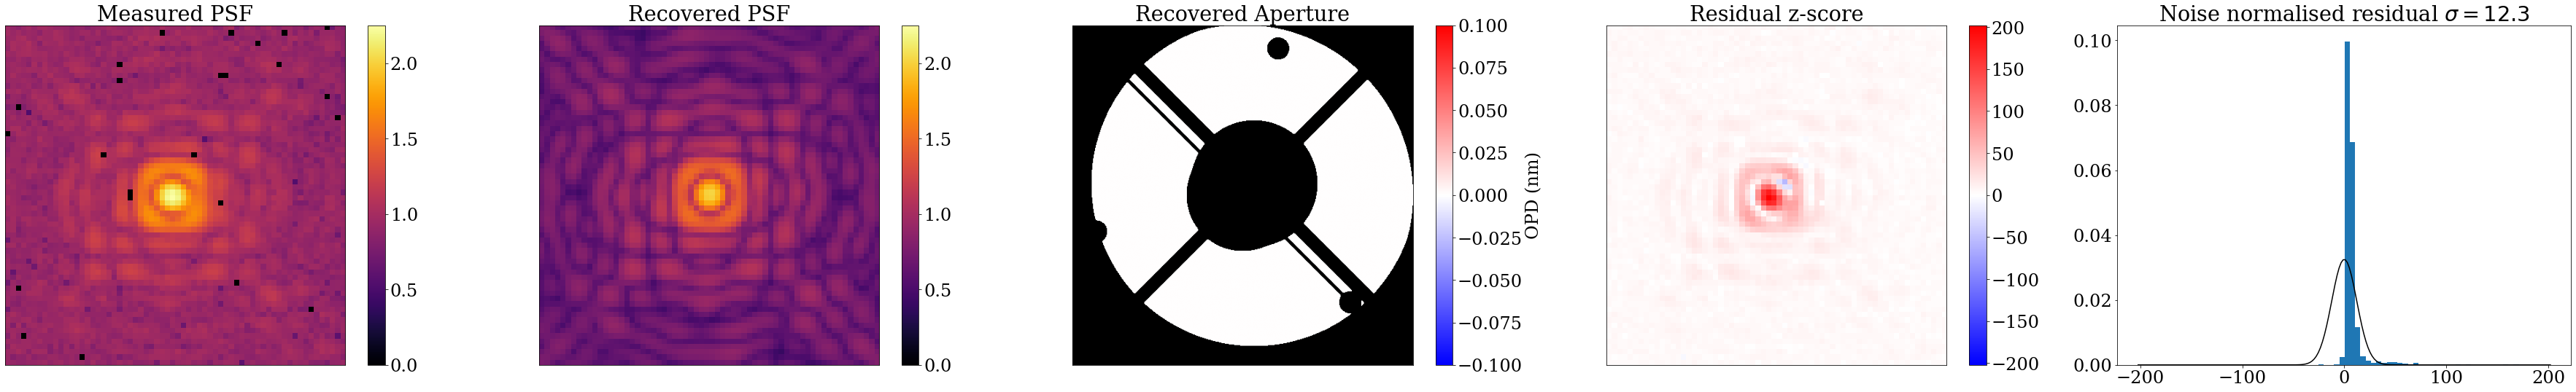

In [8]:
plot_comparison(model_single, params_single, exposures_single)

10.163023472419976
11.730463920383201
12.040697112801583


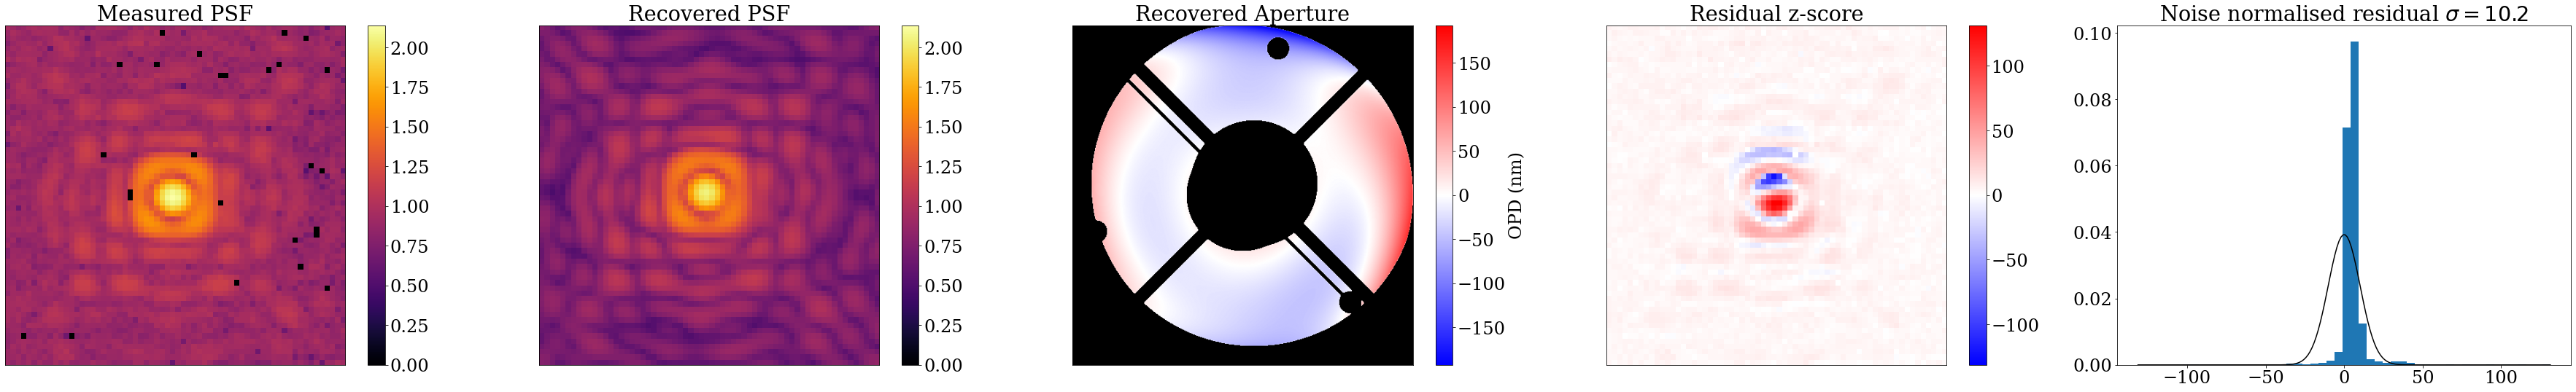

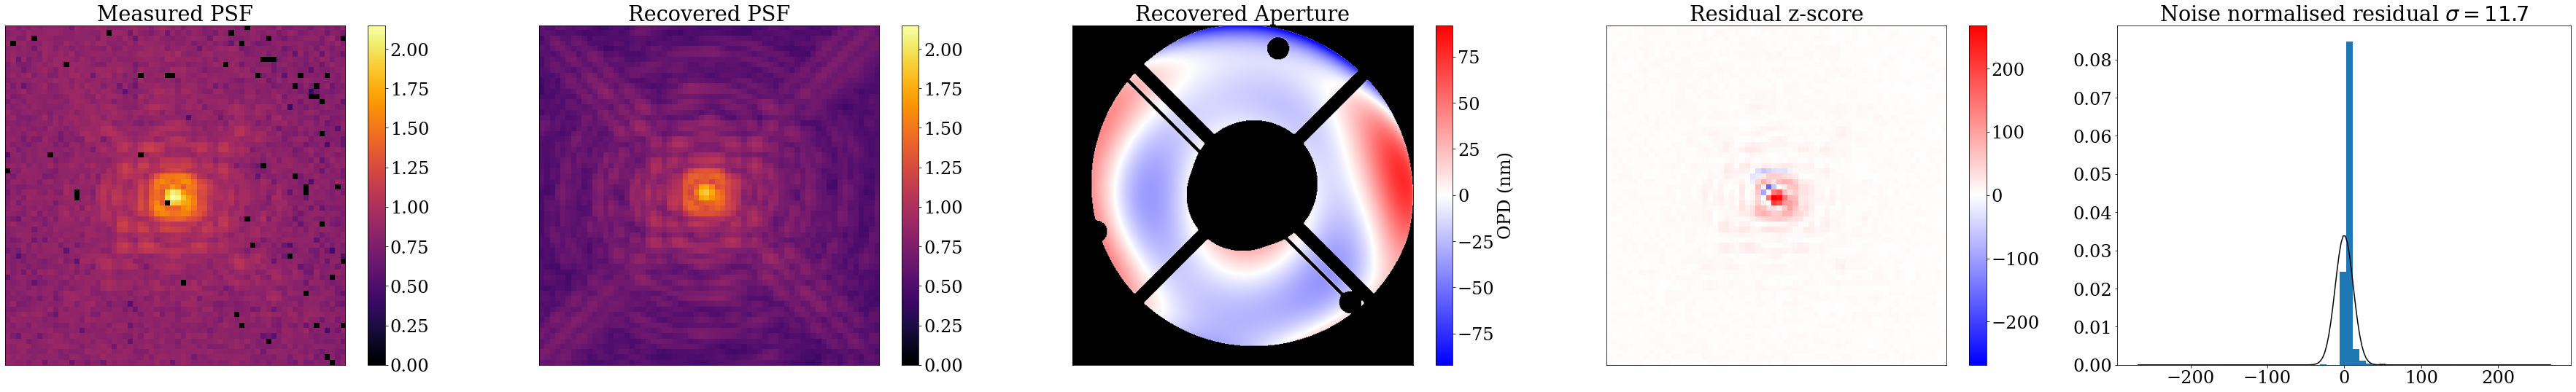

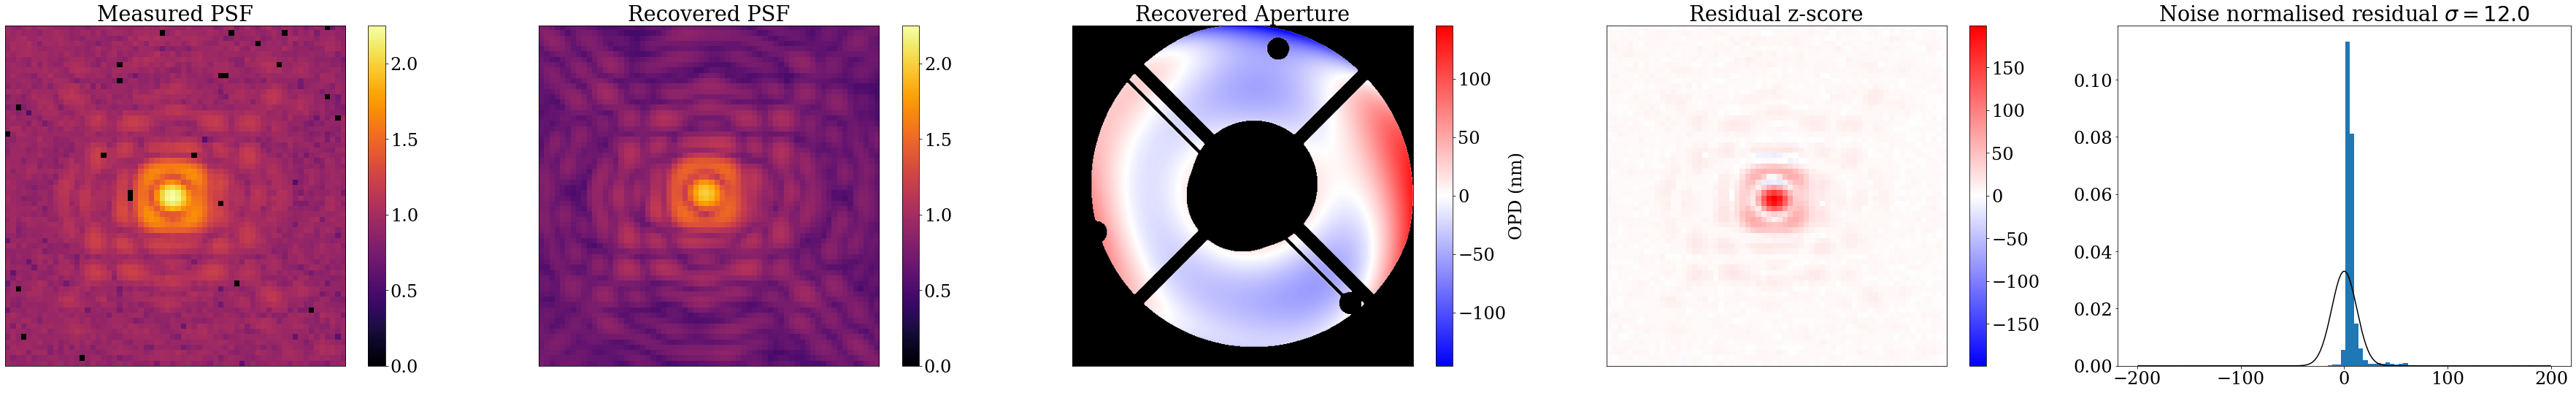

In [9]:
plot_comparison(model_binary, params_binary, exposures_binary)

In [10]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)




g = 5e-2


# things = {
#     "positions": opt(g*5, 0),
#     "position_angle": opt(g*10, 10),
#     "separation": opt(g*15, 20),
#     "primary_spectrum": opt(g*5, 30),
#     "secondary_spectrum": opt(g*3, 30),
#     "cold_mask_shift": opt(g*10, 60),
#     #"cold_mask_rot": opt(g*10, 100),
#     "bias": opt(g*5, 50),
#     "aberrations": opt(g*3, 80),

#     #"cold_mask_scale": opt(g*1, 300),
#     #"cold_mask_shear": opt(g*1, 300),
#     #"primary_scale": opt(g*1, 300),
#     #"primary_shear": opt(g*1, 300),
# }

things_single = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*3, 10),
    "cold_mask_shift": sgd(g*10, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*0.1, 70),
    #"jitter": sgd(g*1, 120),

    "defocus": sgd(g*6, 30),
    "fnumber": sgd(g*3, 100),
    "cold_mask_shear": sgd(g*0.5, 100),
}

things_binary = {
    "positions": sgd(g*2.5, 0),
    "position_angle": sgd(g*10, 10),
    "separation": sgd(g*15, 20),
    "primary_spectrum": sgd(g*5, 30),
    "secondary_spectrum": sgd(g*3, 30),

    "cold_mask_shift": sgd(g*20, 50),
    
    "bias": sgd(g*3, 40),
    "aberrations": sgd(g*0.4, 90),
    #"jitter": sgd(g*1, 120),

    "defocus": sgd(g*0.6, 70),
    "fnumber": sgd(g*3, 110),
    "cold_mask_shear": sgd(g*4, 110),

    "quadrature": sgd(g*20, 900)
}


things_start = {
    "positions": sgd(g*5, 0),
}

In [11]:
orig_params = params_single.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [12]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

5.793821781882644
9.929082302064629
11.275222121333874


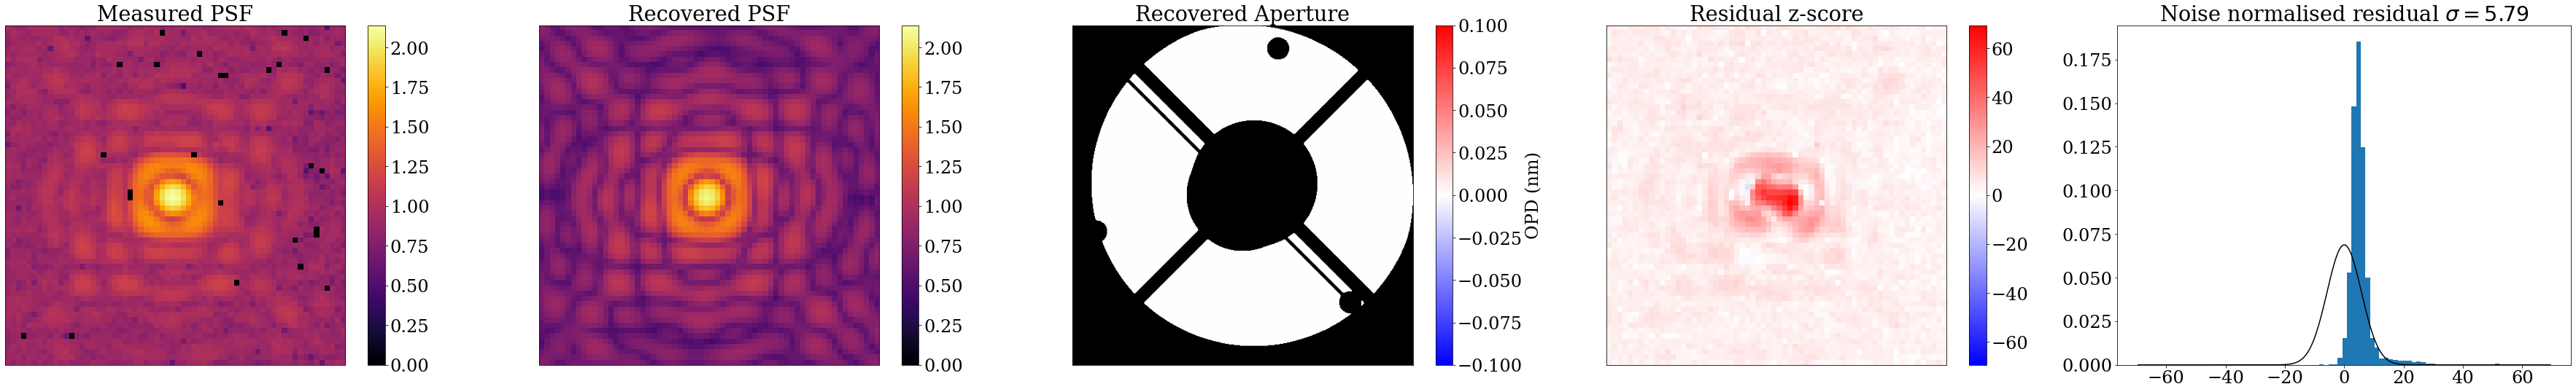

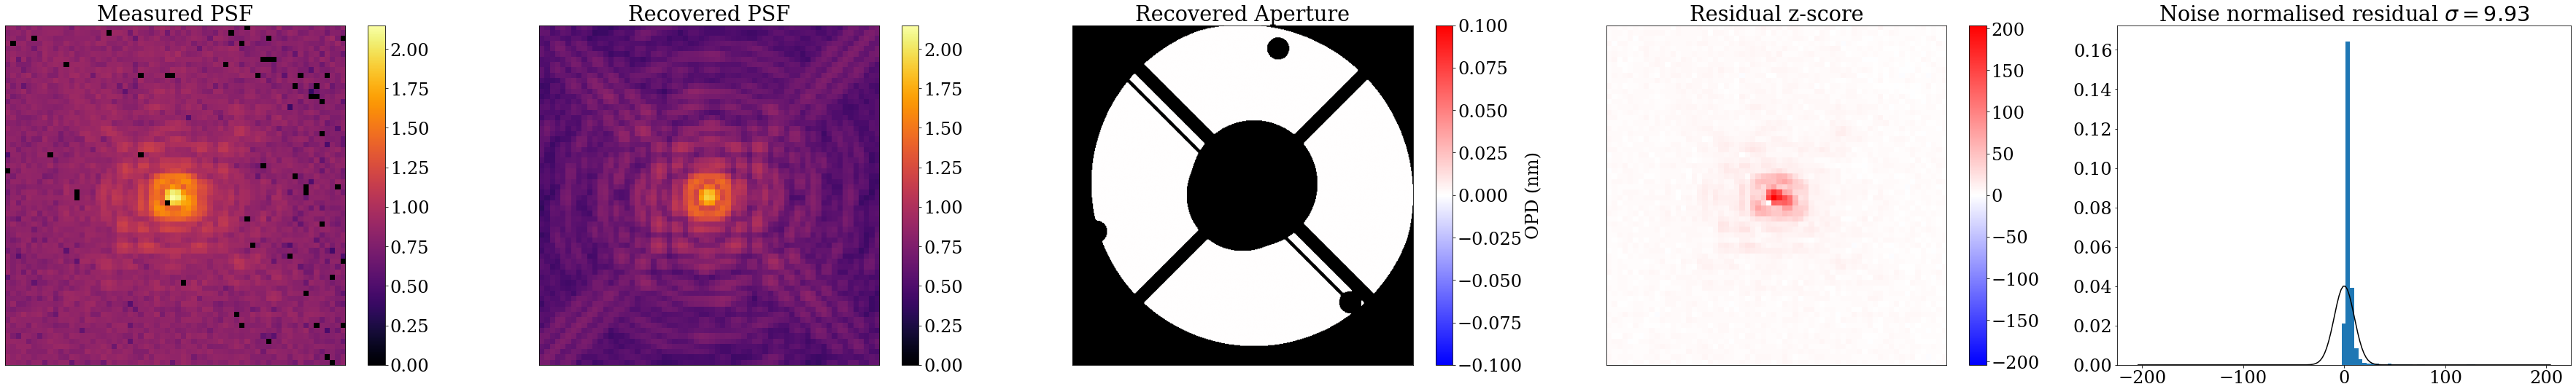

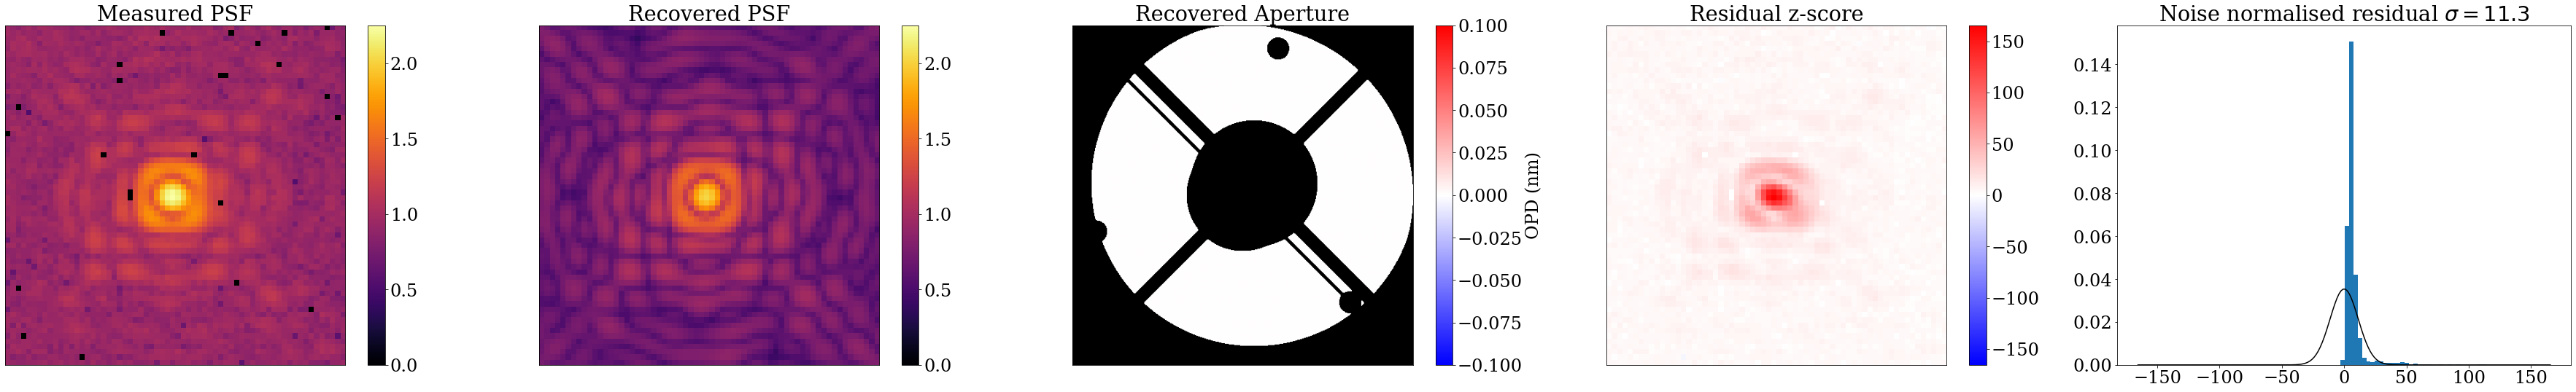

In [13]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [14]:
orig_params = params_single.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_single})

In [ ]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_single, 500, nbatches=len(exposures_single)*2)

  0%|          | 0/500 [00:00<?, ?it/s]

8
3.366927984413215
3.8852637807601442
3.678786386379607


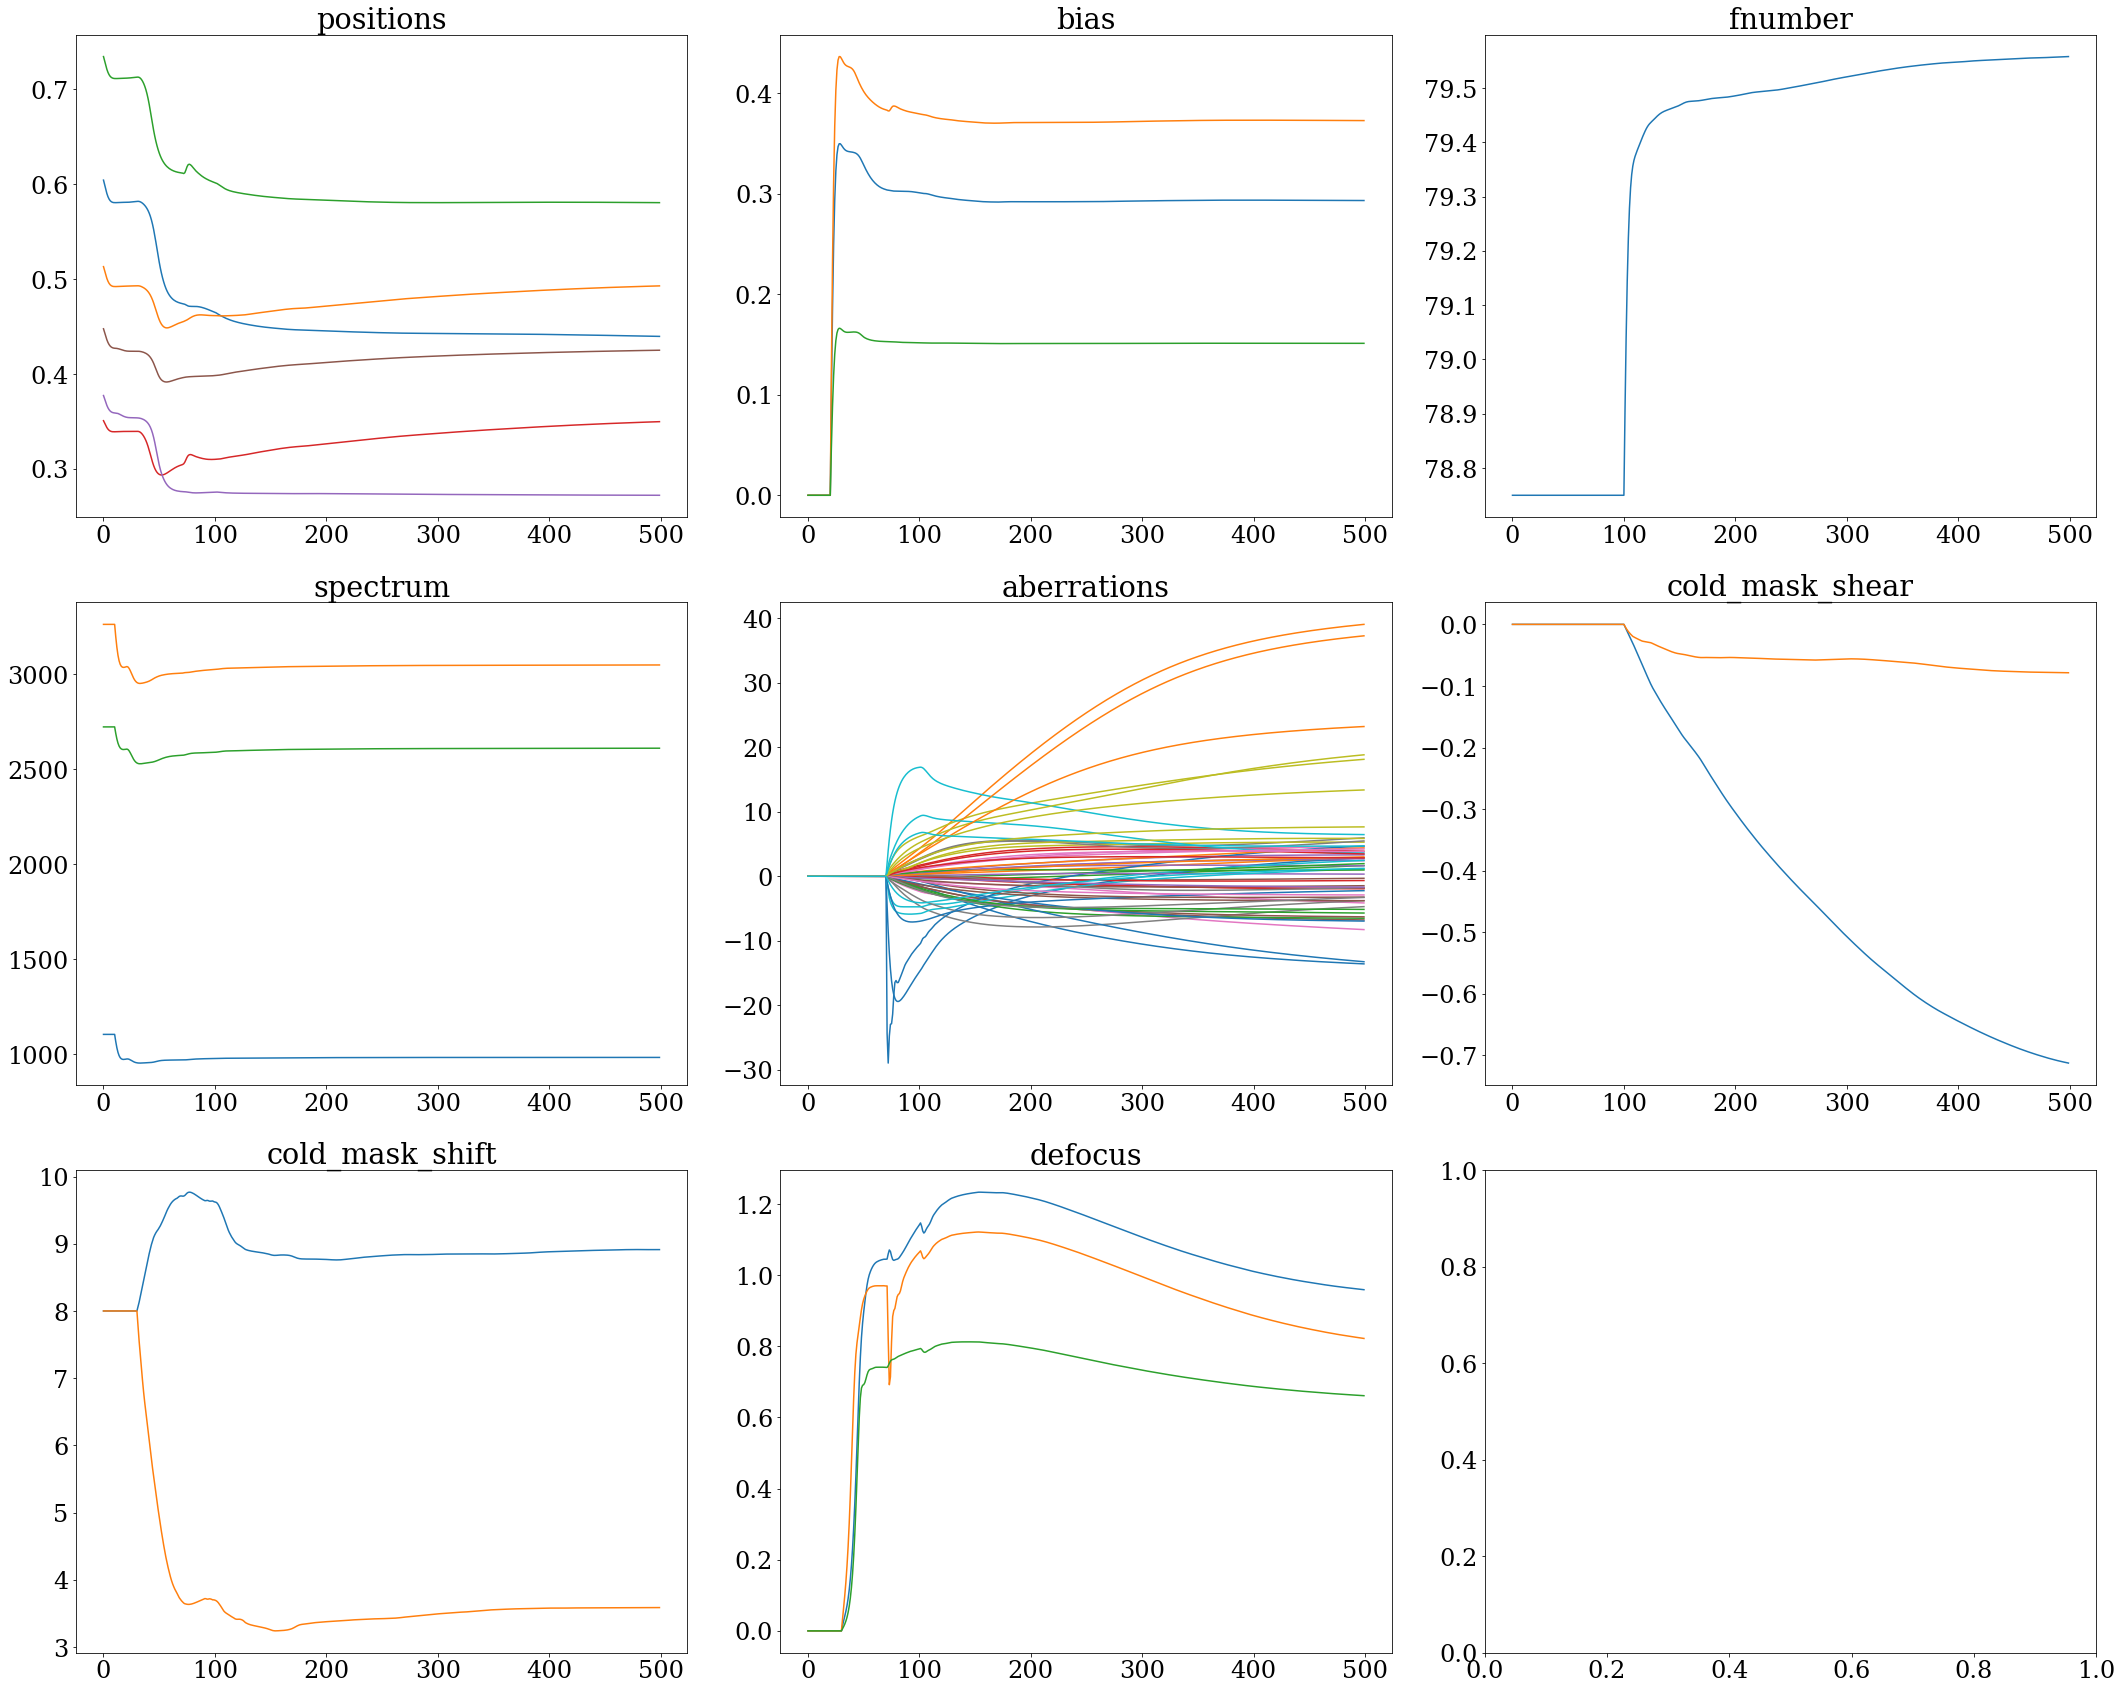

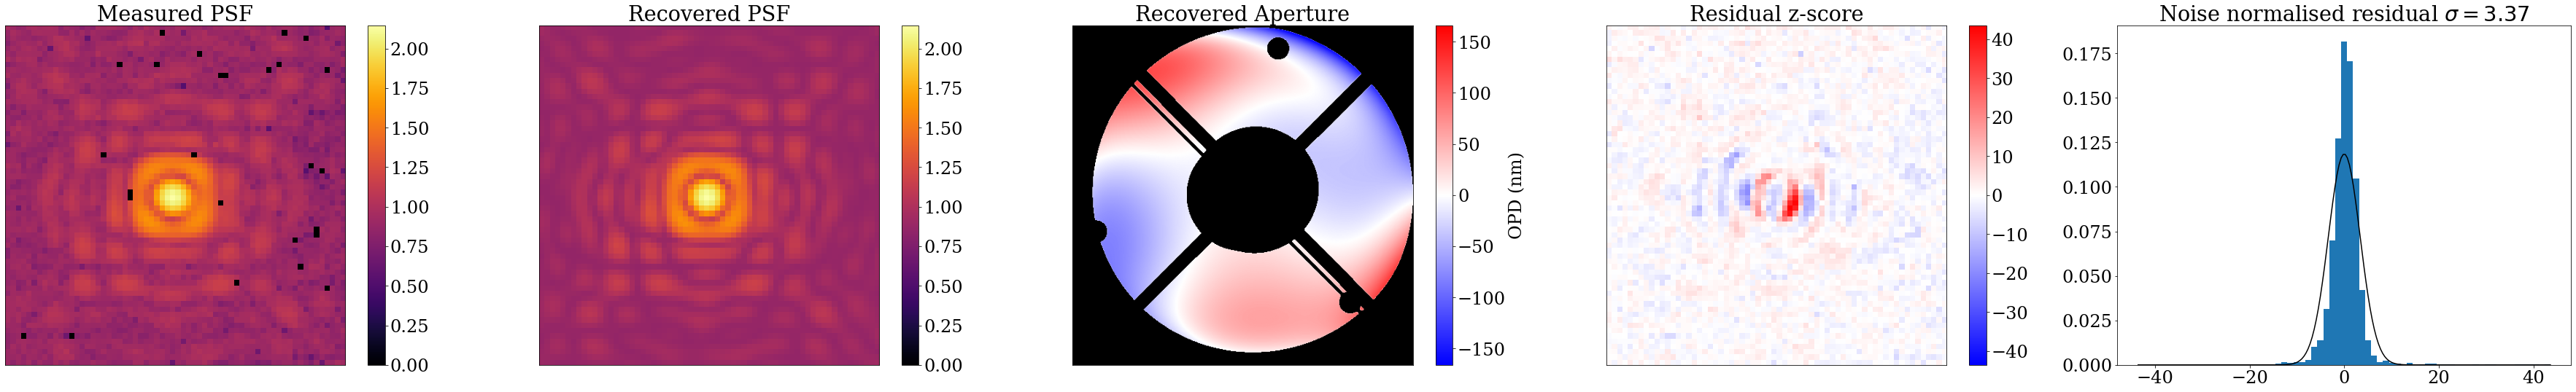

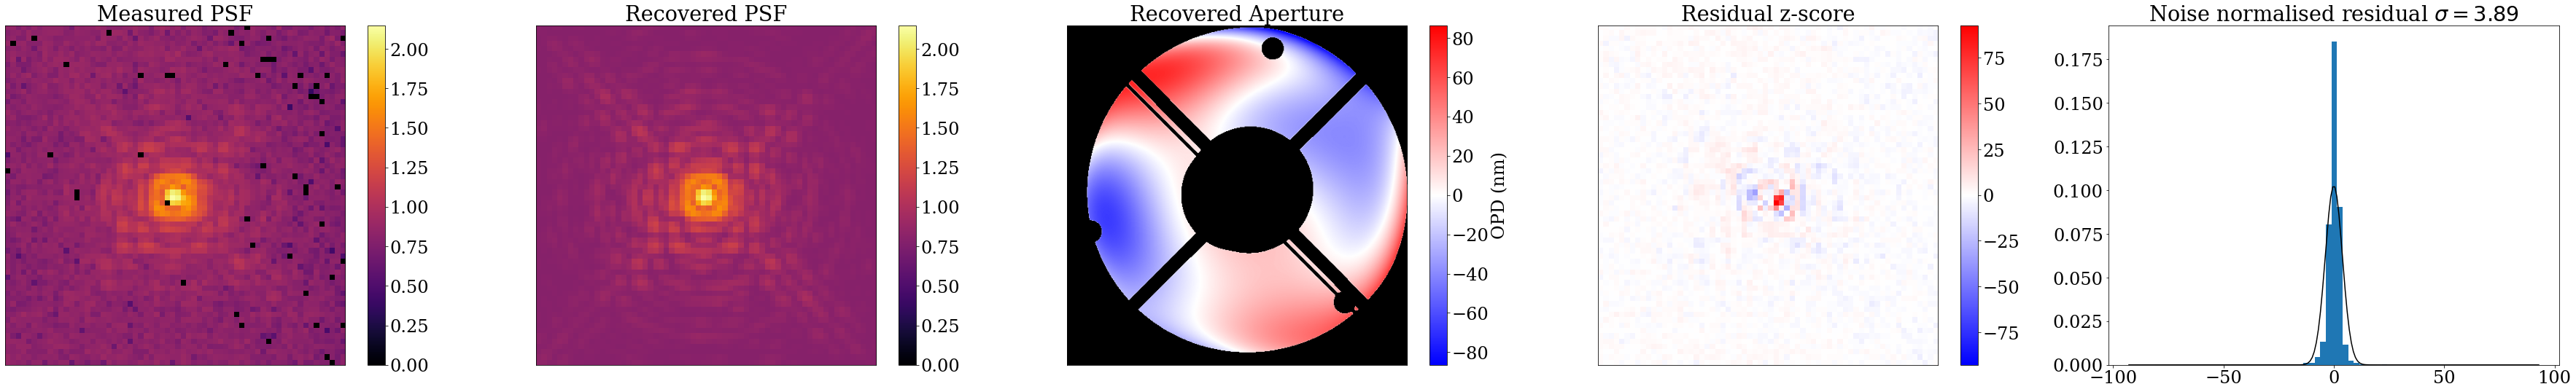

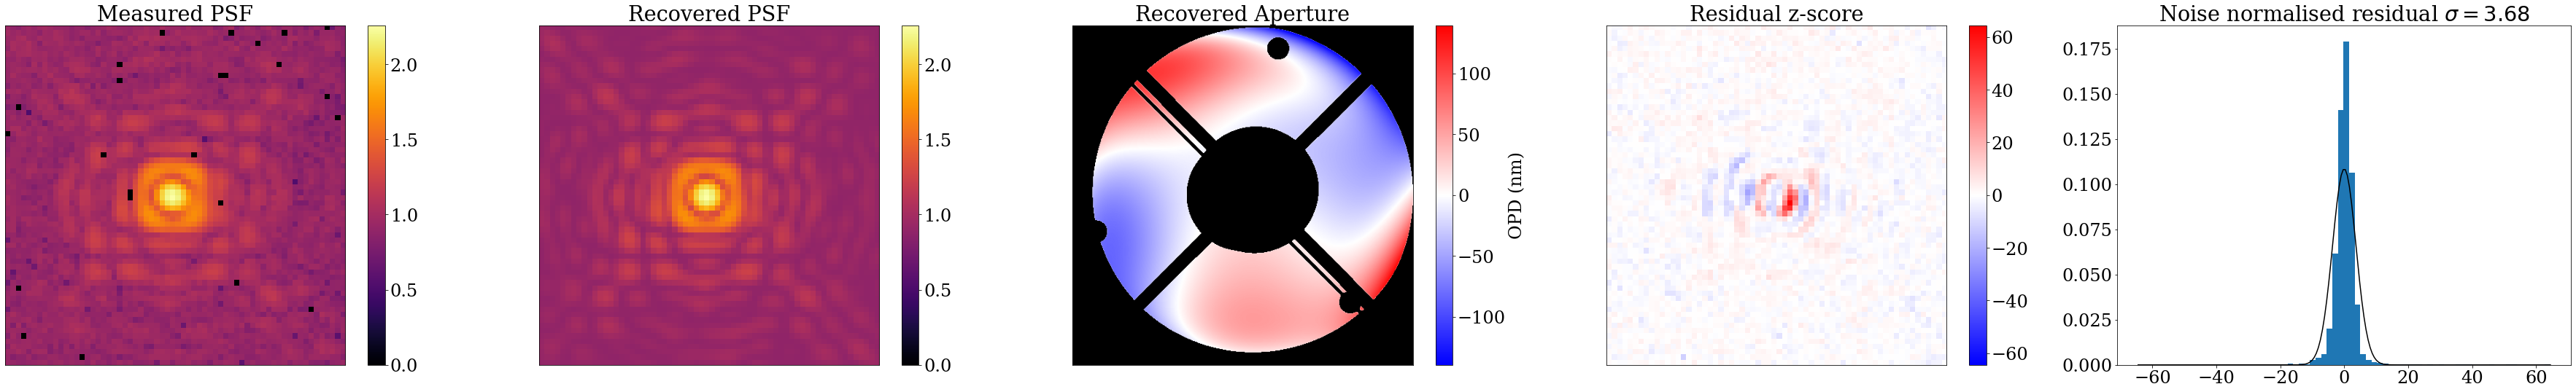

In [ ]:
plot_params(params_history, list(things_single.keys()), xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [ ]:
final_params_single = optimise_optimistix(params_history[-1], model_single, exposures_single)

3.3389404691688145
3.8707871645488483
3.640838483684663


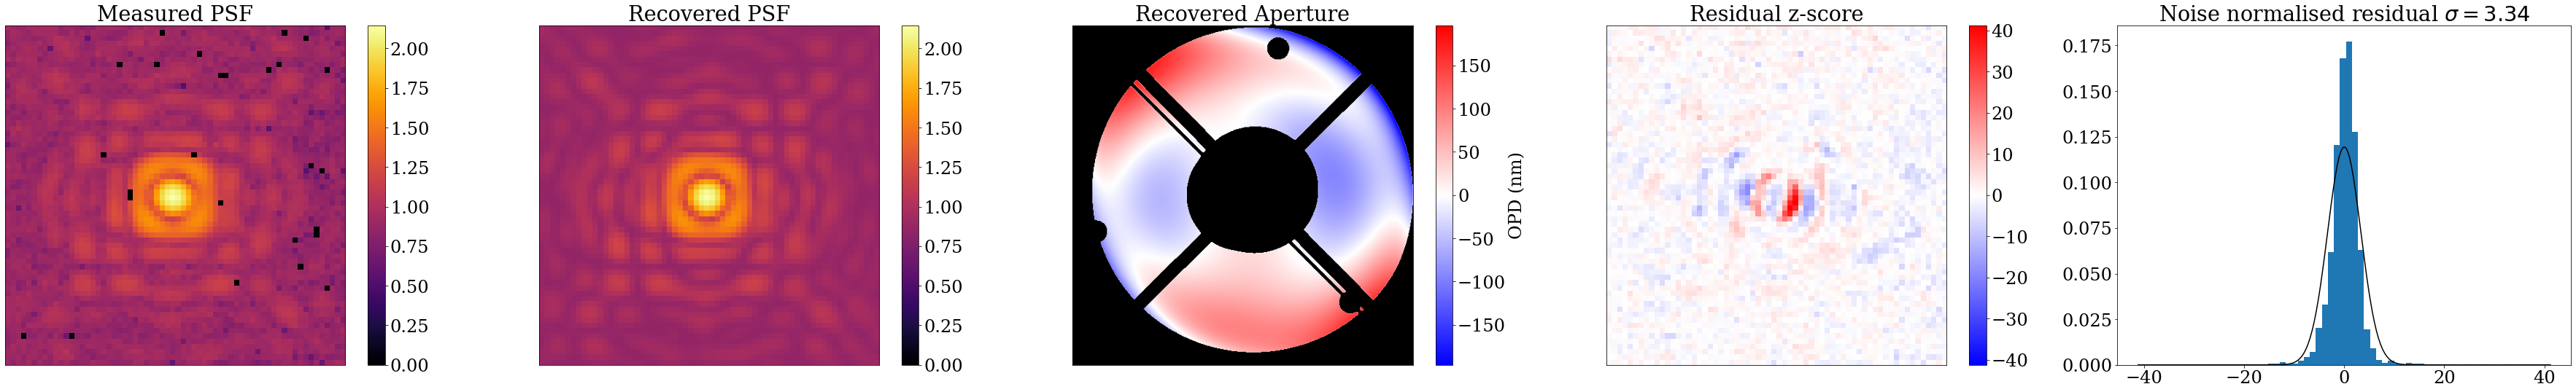

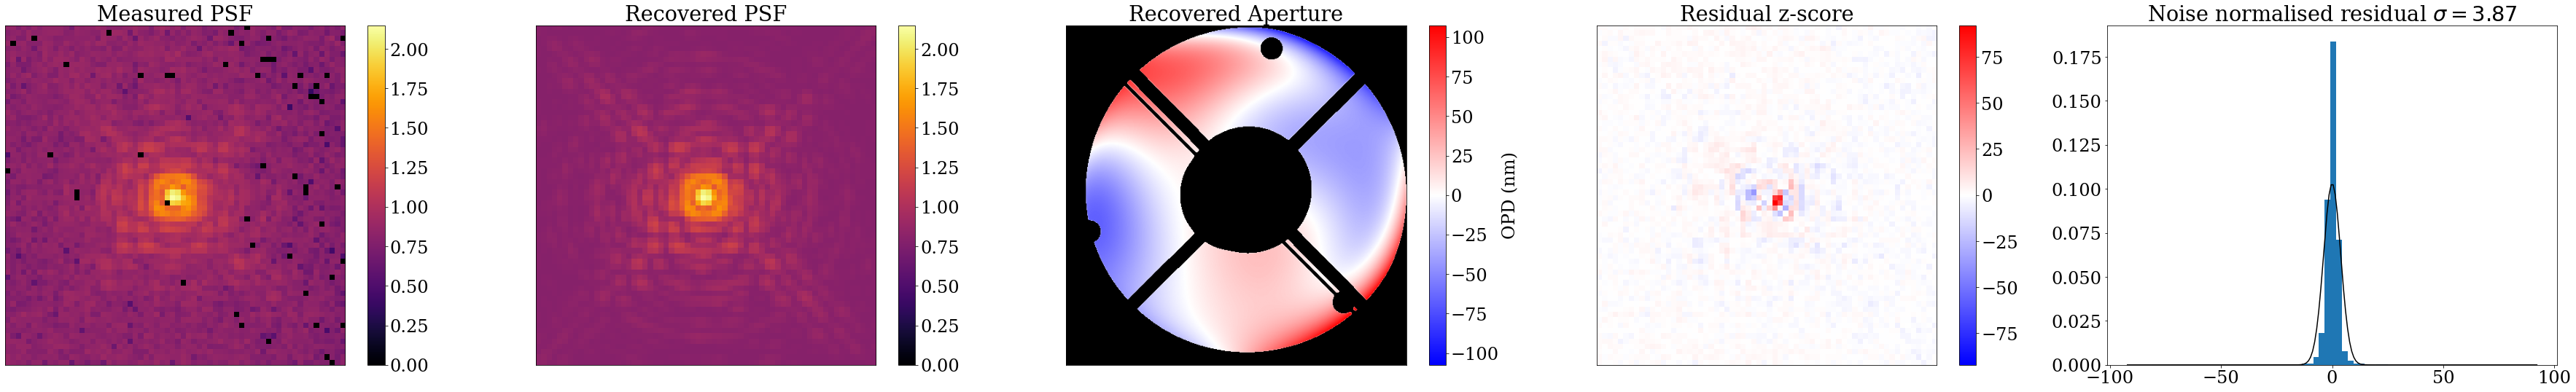

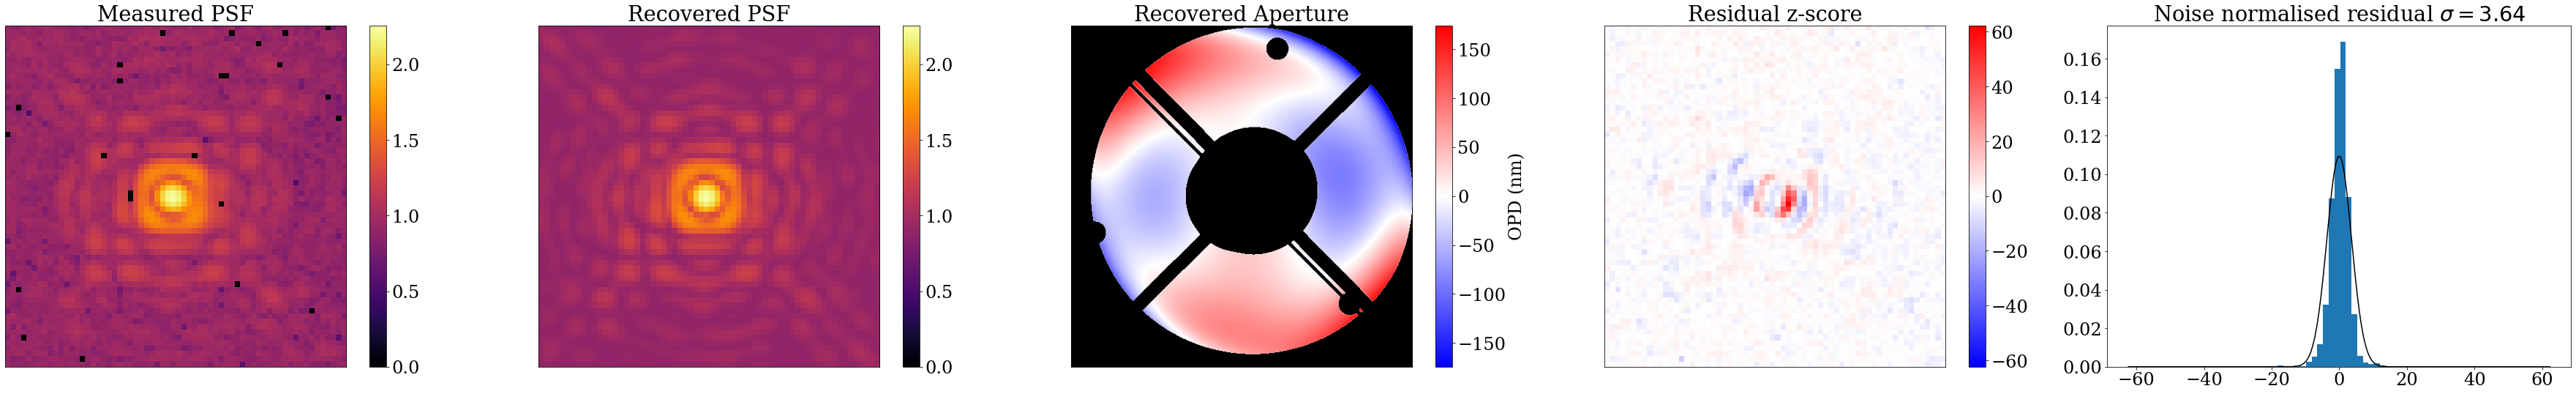

In [ ]:
plot_comparison(final_params_single.inject((model_single)), final_params_single, exposures_single)

In [ ]:
orig_params = params_single.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [ ]:
losses, params_history = optimise_new(opt_params, model_binary, exposures_binary, things_start, 10)

[1.26811349e-06 6.68579321e-07 1.15945173e-06 6.97522849e-07
 3.88351357e-07 4.83656854e-07]


  0%|          | 0/10 [00:00<?, ?it/s]

2.476151273965637
3.029184798057998
2.6250908037358136


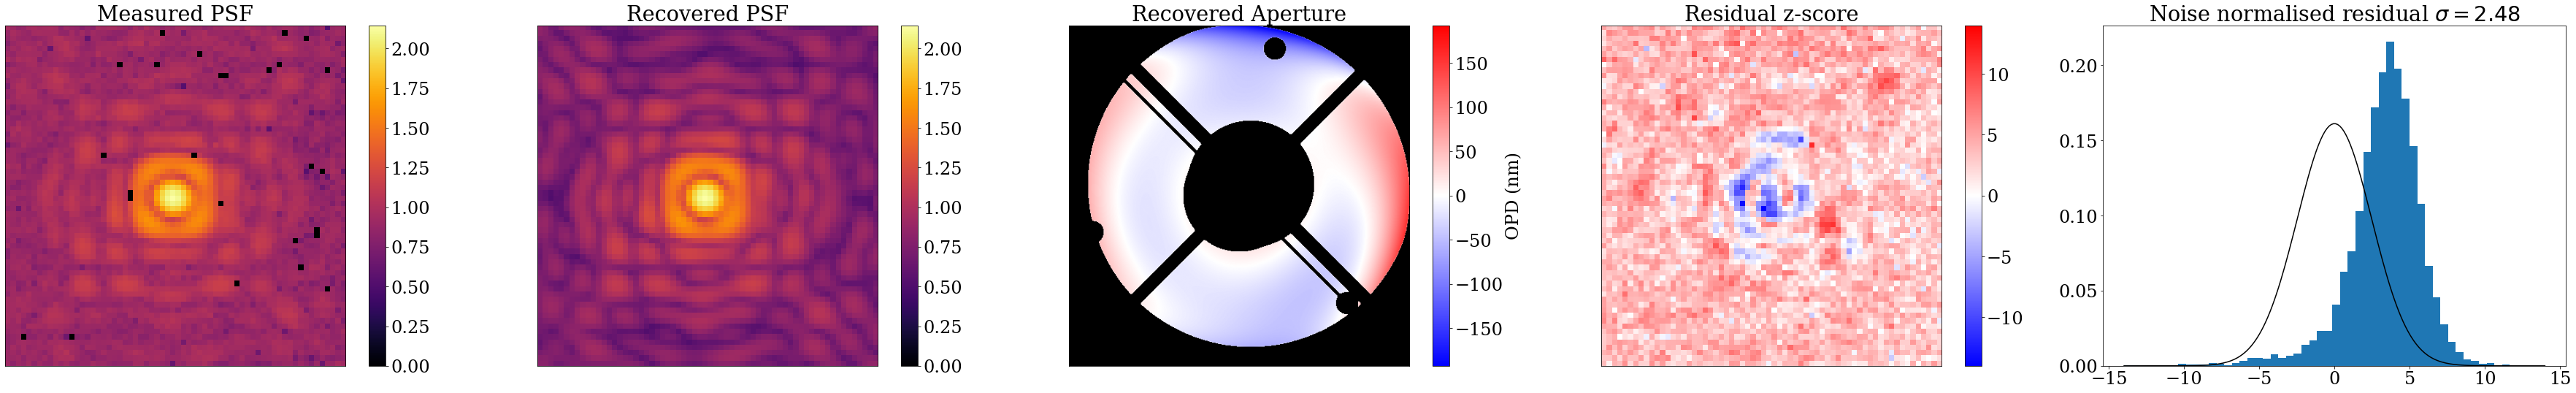

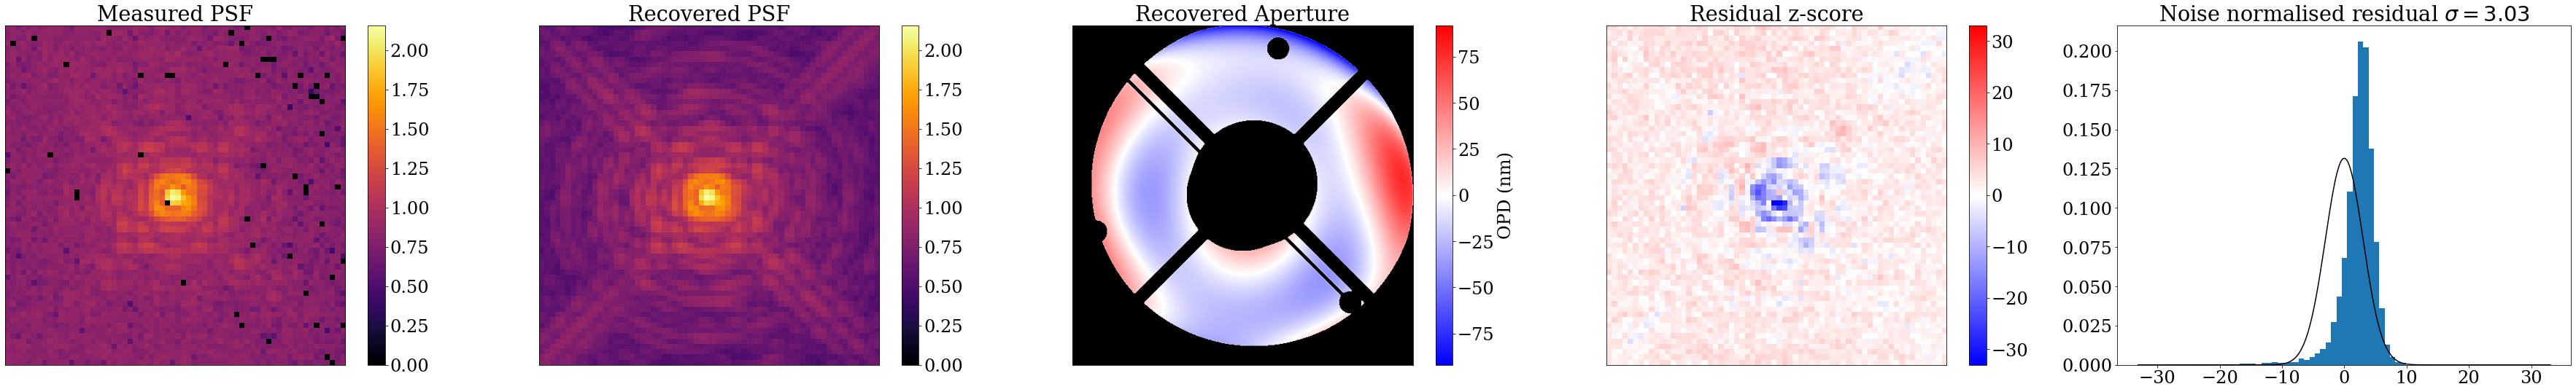

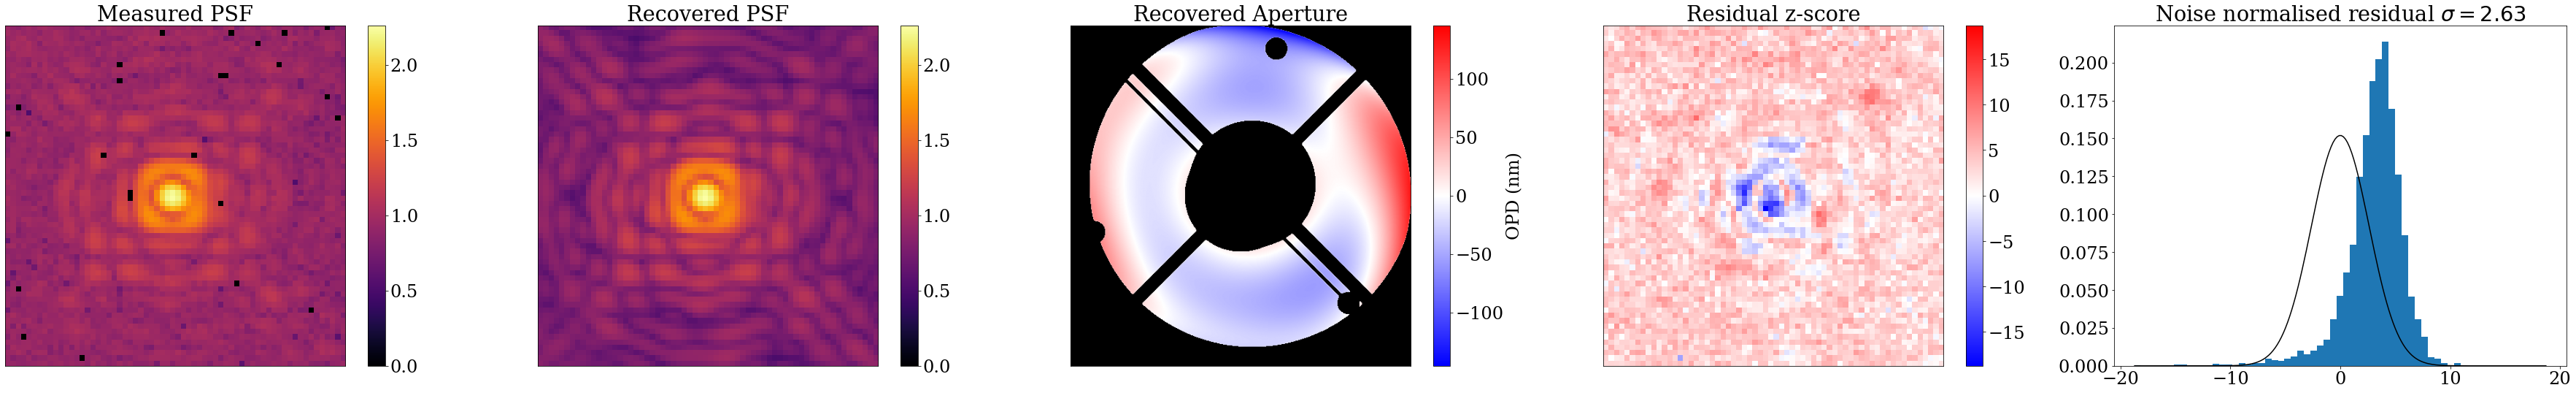

In [ ]:
plot_comparison(model_binary, ModelParams(params_history[-1]), exposures_binary)

In [ ]:
orig_params = params_binary.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_binary})

In [ ]:
losses, params_history = optimise_new(opt_params, model_binary, exposures_binary, things_binary, 1000, nbatches=len(exposures_single)*5)

[3.32008706e-01 3.65066205e-01 3.40559141e-02 2.84200049e-02
 2.34229977e-02 2.35205596e-02 1.56909225e-01 1.14670194e-01
 1.71847444e-01 2.89009896e-01 2.31133940e-01 5.70219601e-02
 7.31661392e-02 2.65616501e-02 2.70872937e-02 5.70300315e-02
 5.64518484e-02 6.98643901e-01 6.99350873e-01 3.56108171e-01
 2.28868692e-01 2.28023603e-01 2.81649410e-02 2.30854357e-02
 1.89580173e-02 1.94541704e-02 1.16097169e-01 7.94288988e-02
 1.26536623e-01 1.90245145e-01 1.47892991e-01 4.45672608e-02
 5.57736766e-02 2.19862360e-02 2.15350330e-02 4.53359343e-02
 4.50450990e-02 3.25416897e-01 3.72213825e-01 1.88743116e-01
 1.29110561e-01 1.16288033e-01 1.90624613e-02 1.47828563e-02
 1.26482089e-02 1.29677535e-02 6.51927261e-02 4.66834625e-02
 6.66357694e-02 9.93983339e-02 7.98684760e-02 2.66602172e-02
 3.11084397e-02 1.46100539e-02 1.38051865e-02 2.89319792e-02
 2.96995266e-02 1.10567130e-01 1.08427246e-01 7.20025887e-02
 1.94986874e-06 3.21396704e-06 7.89863650e-07 3.03423532e-04
 2.71467879e-04 1.719777

  0%|          | 0/1000 [00:00<?, ?it/s]

12
0.9970061453062385
0.9990514570240154
0.9979690043146069


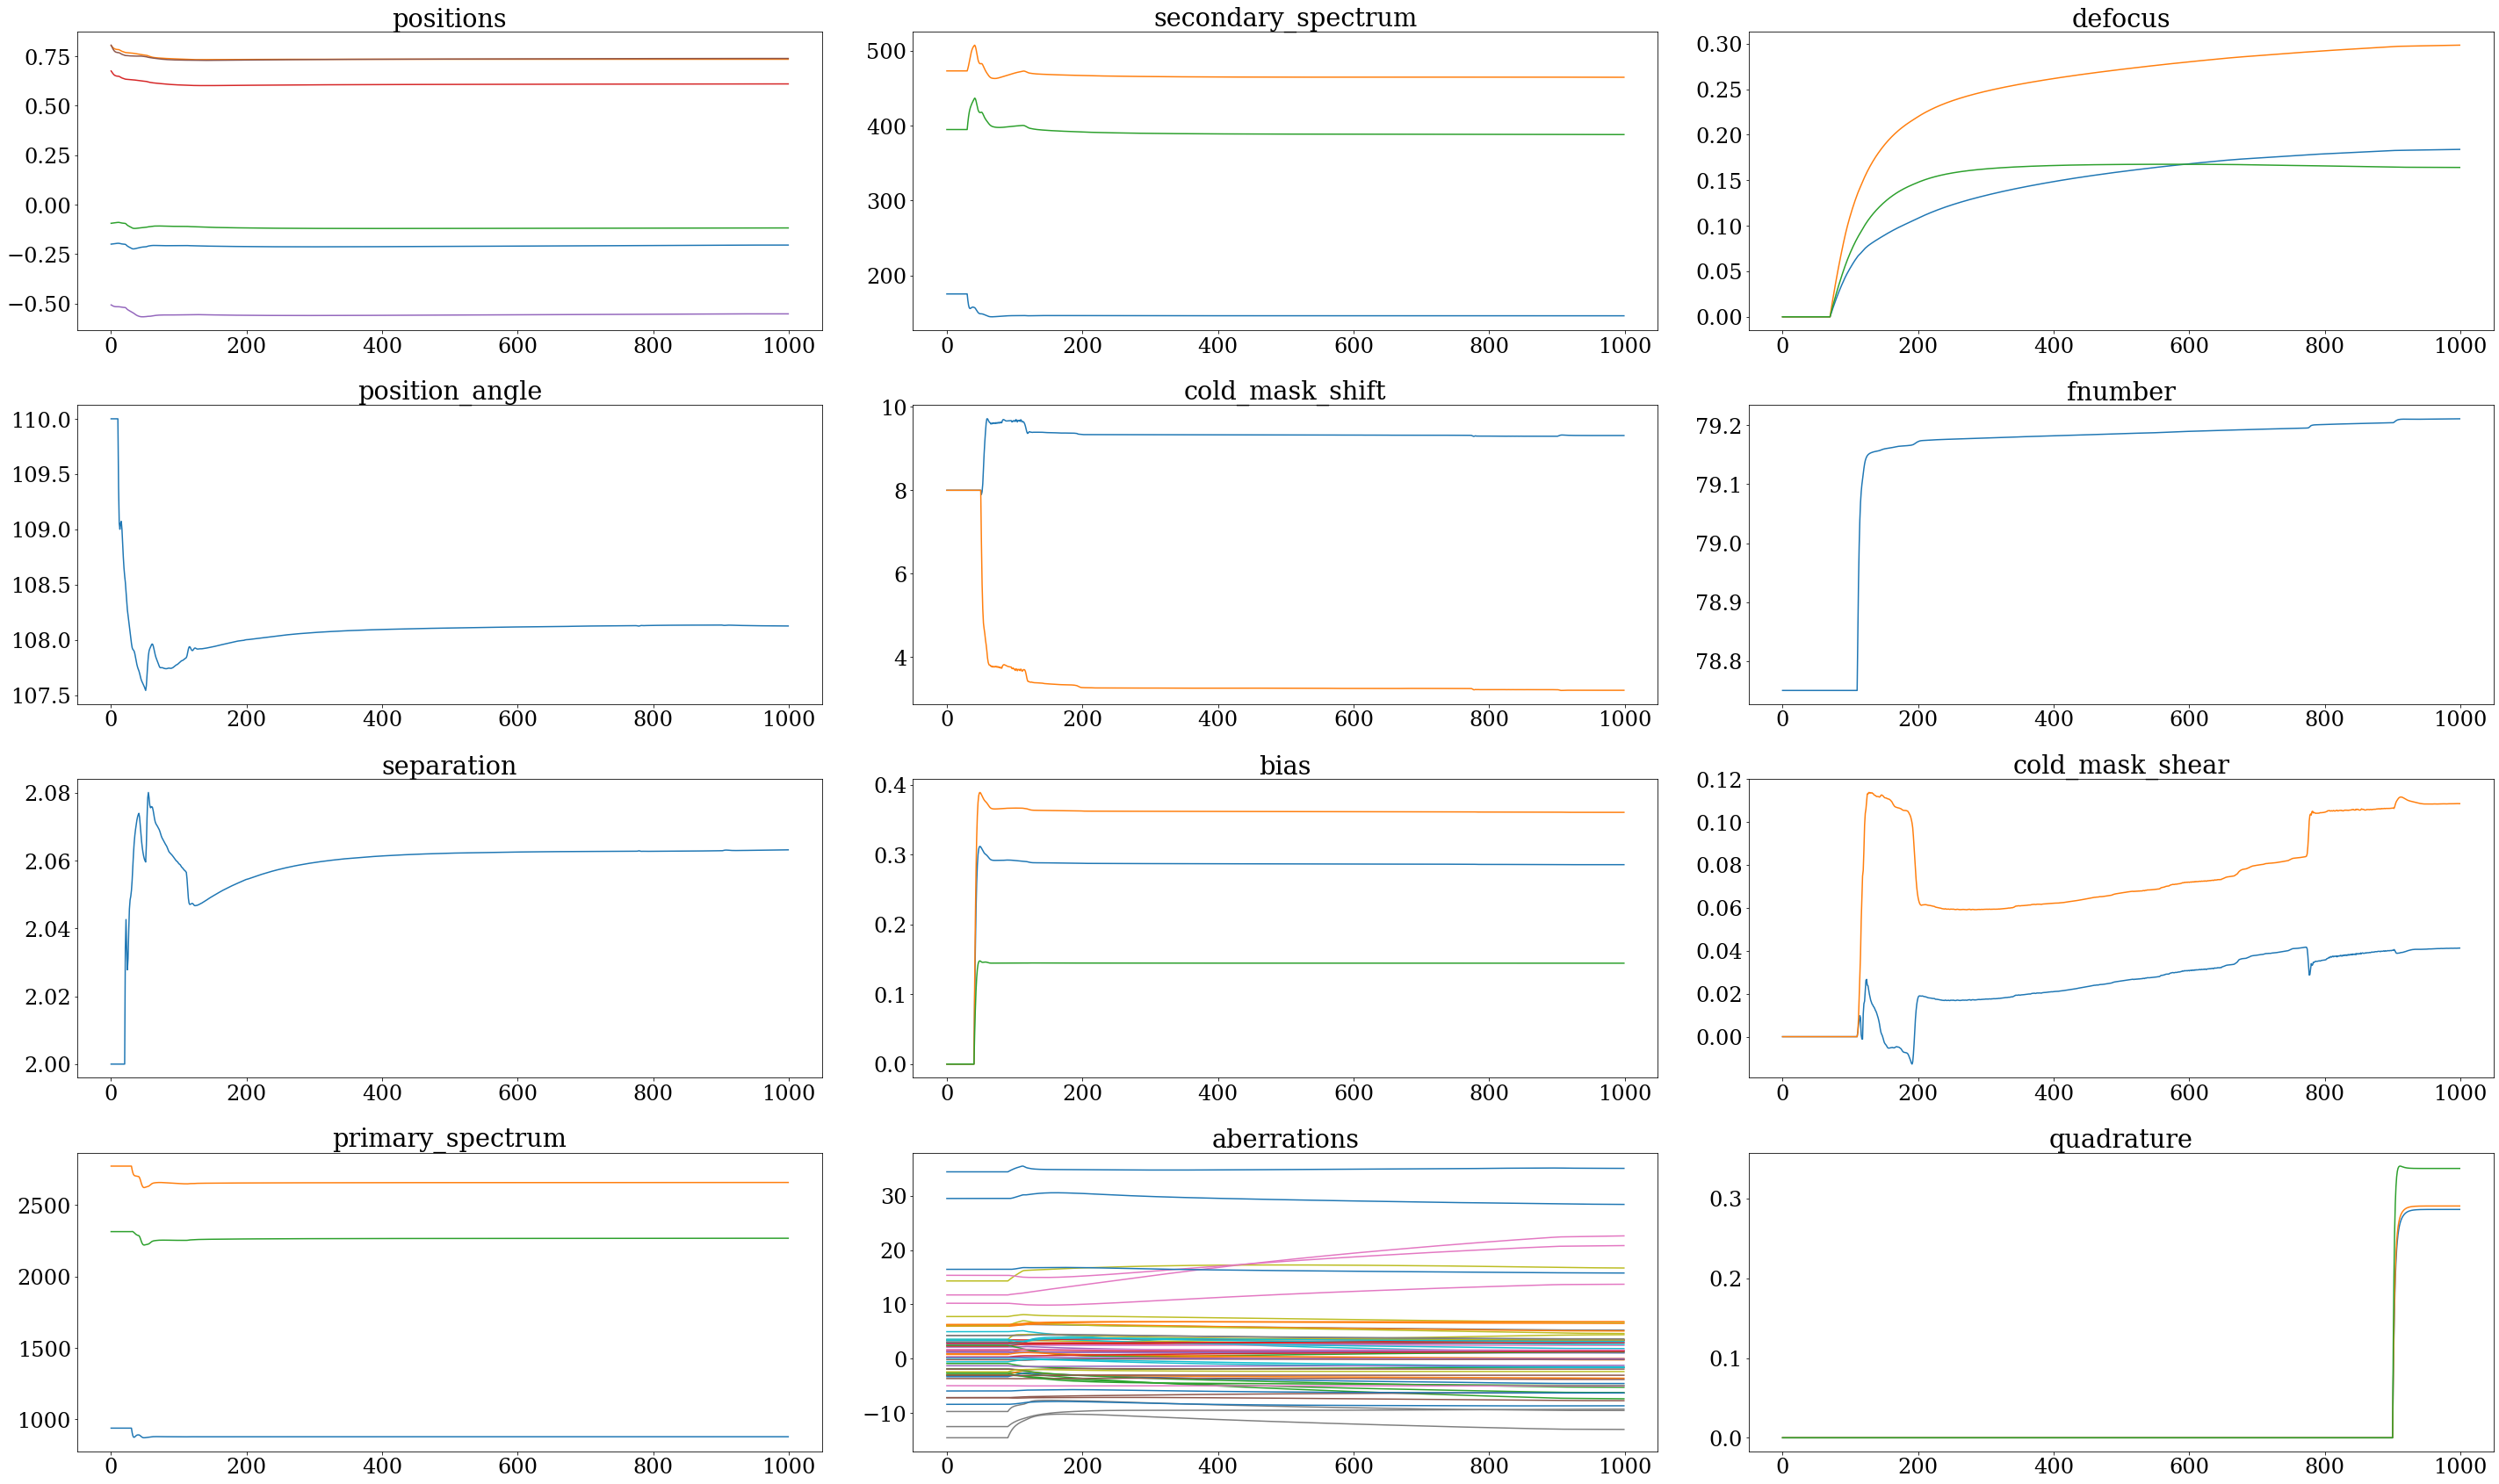

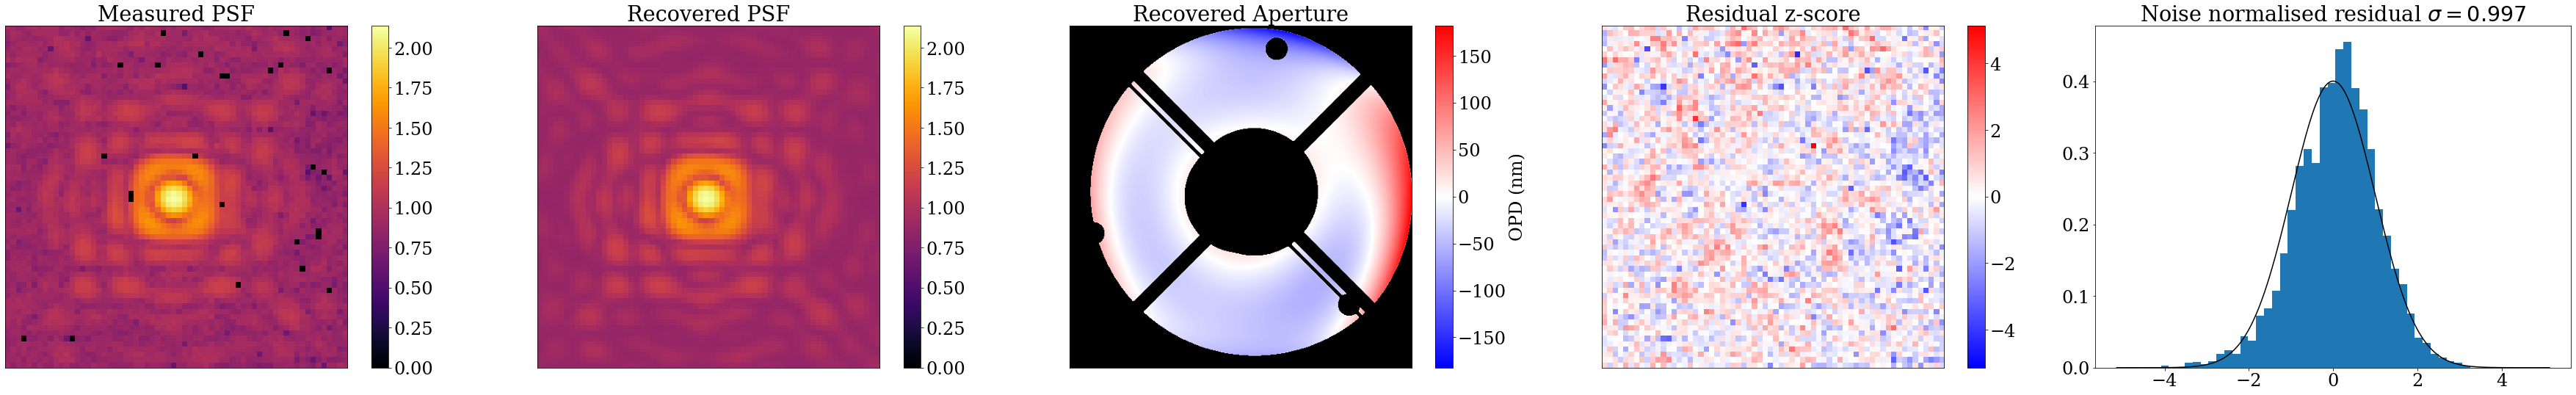

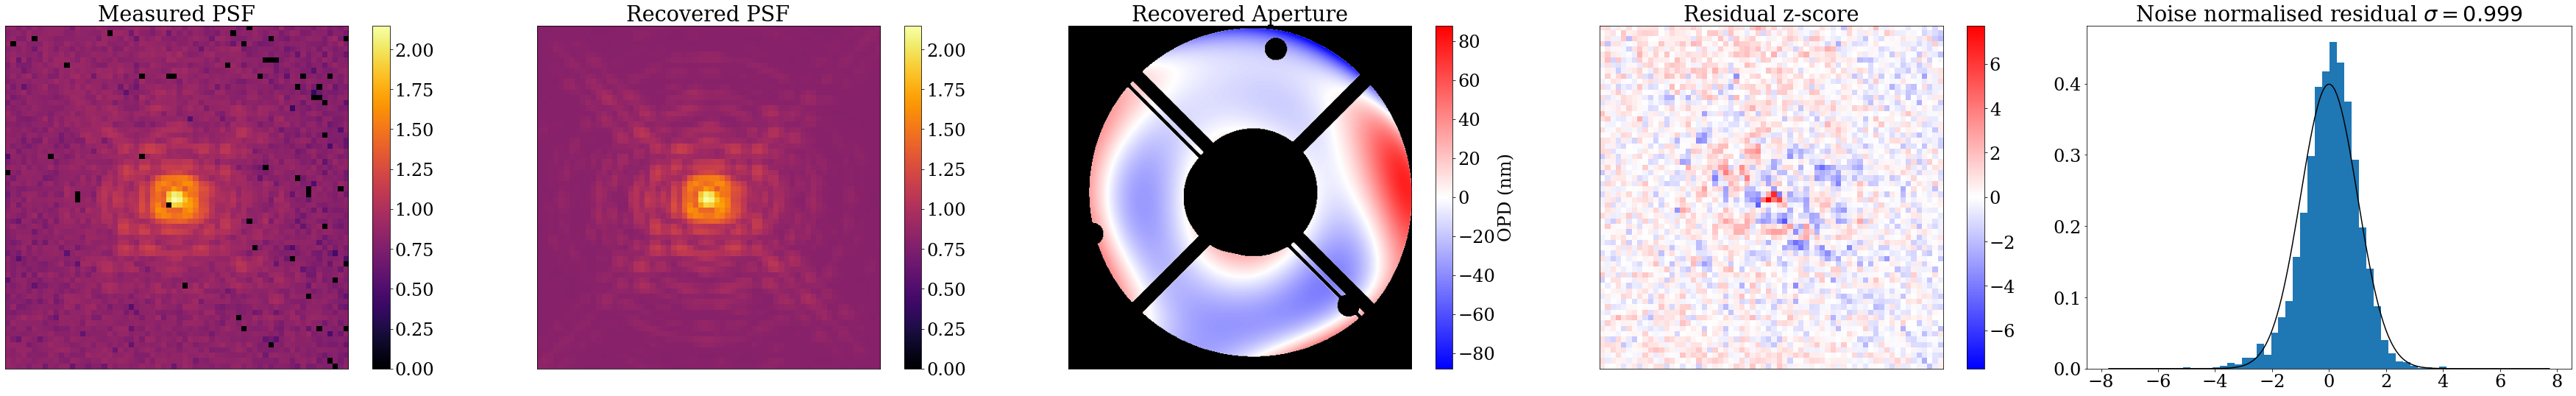

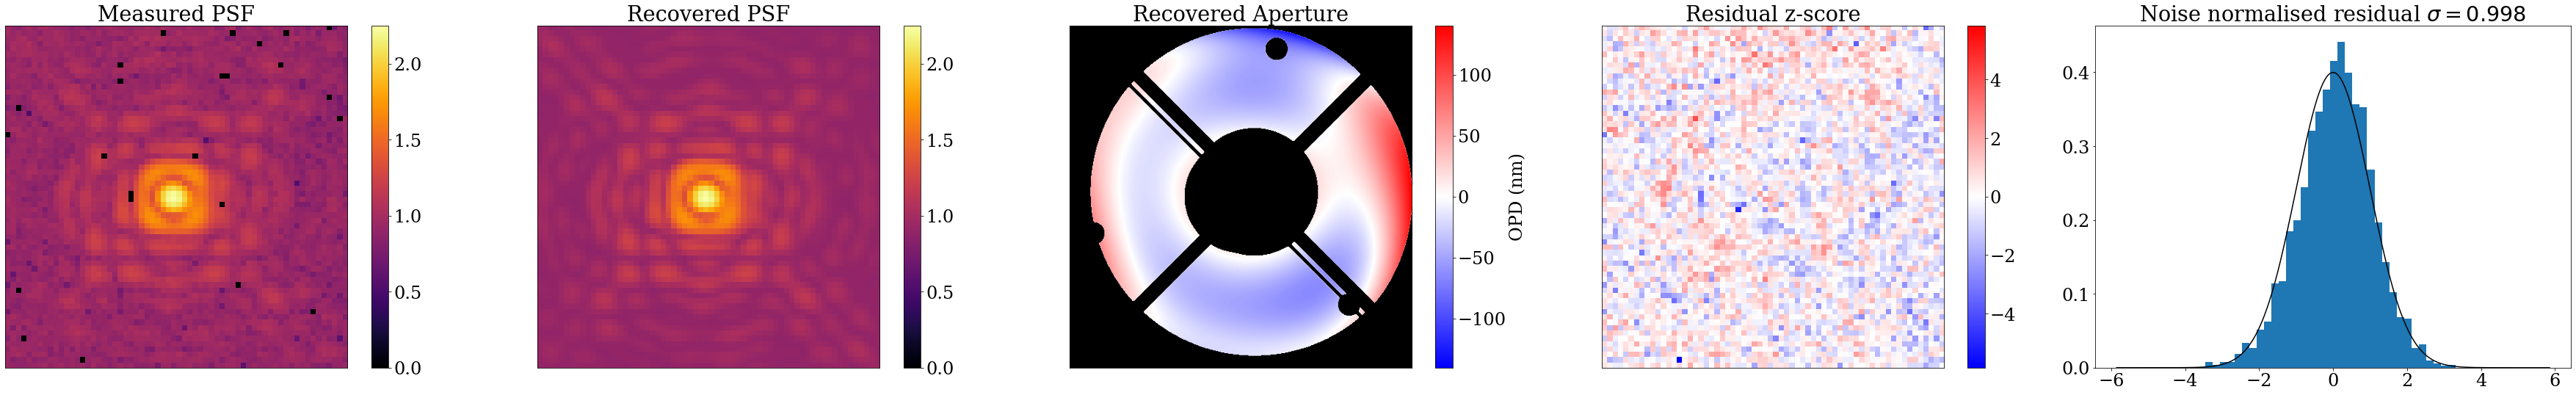

In [ ]:
plot_params(params_history, list(things_binary.keys()), xw = 4)
plot_comparison(model_binary, ModelParams(params_history[-1]), exposures_binary, quadrature=True)

In [ ]:
params_history[-1]

{'aberrations': {'n8o101a1q': Array([35.02411351, -0.19964795, -7.36334186,  1.49657375,  1.46700612,
         -6.27557938, 22.6057517 ,  5.2763234 , 16.6950496 ,  1.1104805 ,
         -4.55211433,  5.10736849, -1.58936355,  3.37381594,  2.96045132,
         -0.14224778,  2.45823942, -9.51427626,  4.42598737,  1.87390841],      dtype=float64),
  'n8o101a8q': Array([ 28.39364589,  -3.57723121,  -5.24700232,   3.44365749,
           1.08161246,  -7.71153978,  20.8185875 ,   3.4664056 ,
           4.64208111,  -1.49350833,  -8.6496677 ,   6.49462162,
           1.24415304,   3.39942338,   1.42937412,  -1.89256224,
           1.59257006, -12.99881622,   3.44731914,   2.64669   ],      dtype=float64),
  'n8o101adq': Array([ 1.57733744e+01,  4.38505909e-02, -6.22445529e+00,  1.38351549e+00,
         -5.43390671e-03, -3.79971626e+00,  1.37080858e+01,  3.66390605e+00,
          6.69611639e+00, -1.62435078e+00, -6.29002024e+00,  6.83703825e+00,
         -4.90693324e+00,  2.97010720e+00, -1.2198

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
final_params_binary = optimise_optimistix(params_history[-1], model_binary, exposures_binary)

In [ ]:
print((final_params_binary["primary_spectrum"]["GL164_F108N"]/final_params_binary["secondary_spectrum"]["GL164_F108N"]))
print((final_params_binary["primary_spectrum"]["GL164_F164N"]/final_params_binary["secondary_spectrum"]["GL164_F164N"]))
print((final_params_binary["primary_spectrum"]["GL164_F190N"]/final_params_binary["secondary_spectrum"]["GL164_F190N"]))


[6.01583615]
[5.72422026]
[5.86209927]


0.9971642424883198
0.9990622106185758
0.9980485893678598


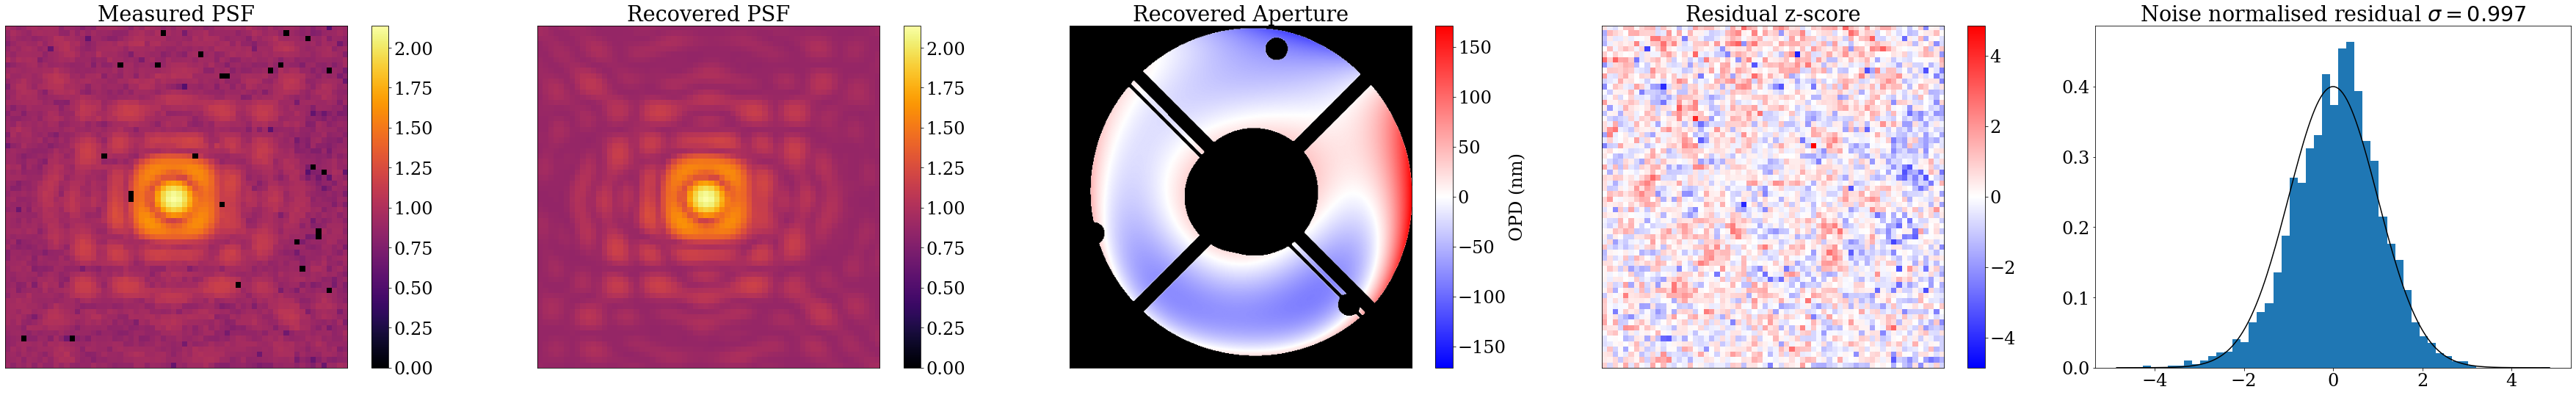

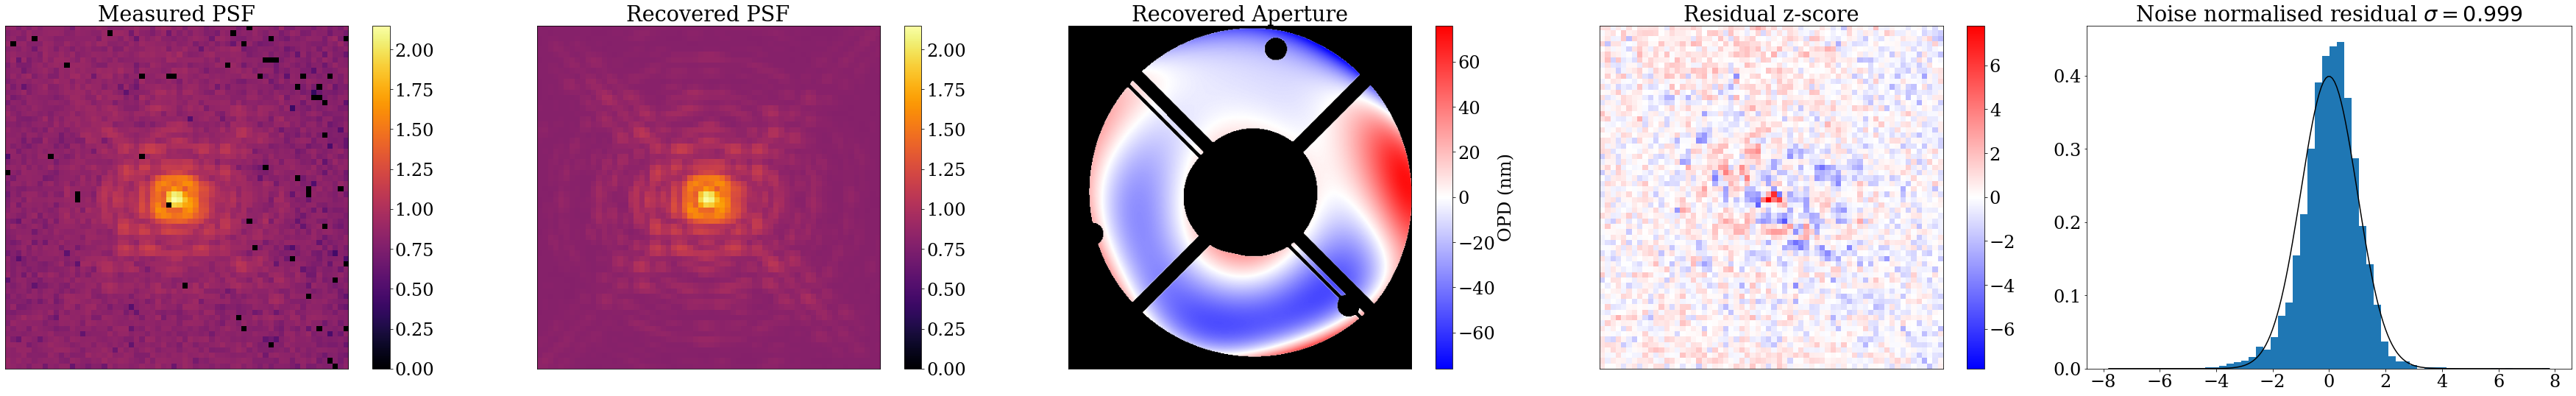

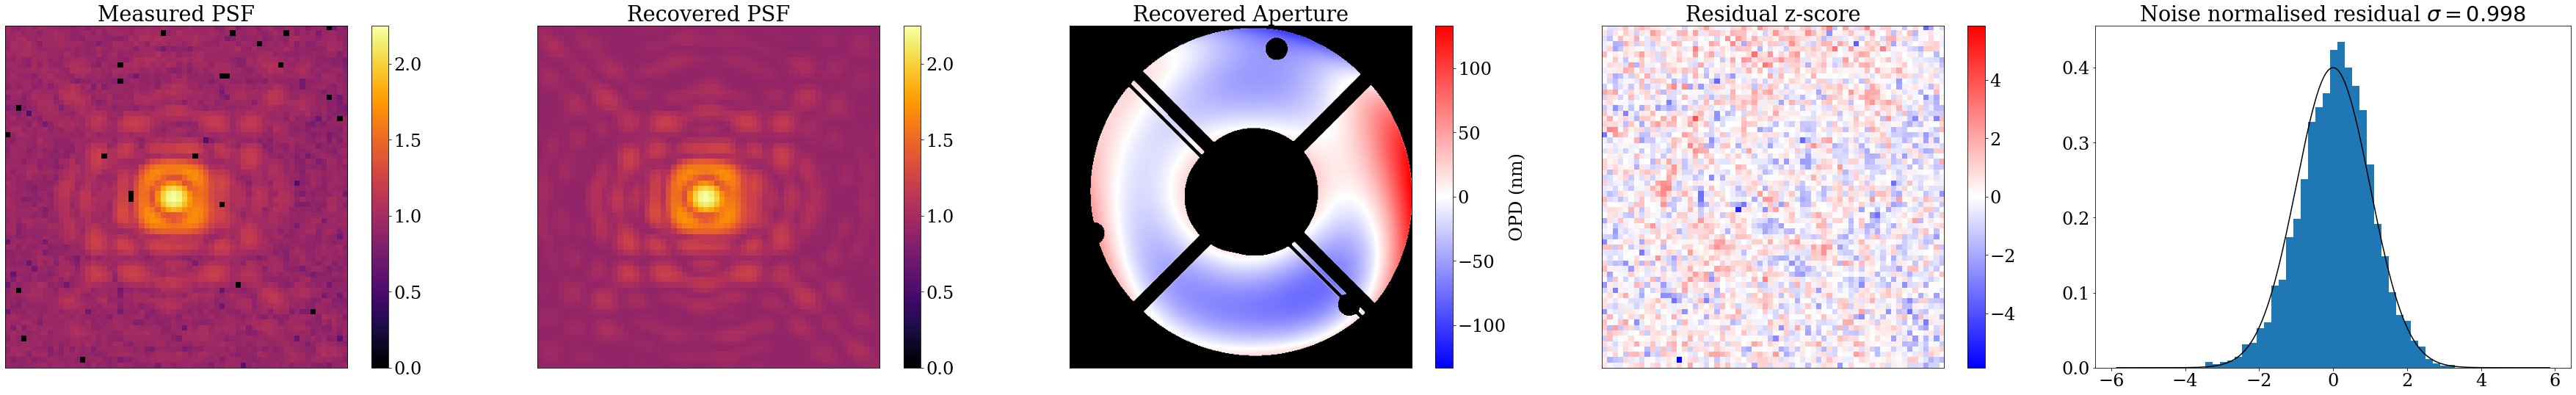

In [ ]:
plot_comparison(final_params_binary.inject((model_binary)), final_params_binary, exposures_binary, quadrature=True)

In [ ]:
final_params_single

ModelParams(
  params={
    'aberrations':
    {'n8o101a1q': f64[12], 'n8o101a8q': f64[12], 'n8o101adq': f64[12]},
    'bias': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'fnumber': f64[],
    'positions': {'n8o101a1q': f64[2], 'n8o101a8q': f64[2], 'n8o101adq': f64[2]},
    'spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]}
  }
)

In [ ]:
final_params_binary

ModelParams(
  params={
    'aberrations':
    {'n8o101a1q': f64[12], 'n8o101a8q': f64[12], 'n8o101adq': f64[12]},
    'bias': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'fnumber': f64[],
    'position_angle': f64[],
    'positions': {'n8o101a1q': f64[2], 'n8o101a8q': f64[2], 'n8o101adq': f64[2]},
    'primary_spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]},
    'quadrature': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'secondary_spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]},
    'separation': f64[]
  }
)

In [ ]:
positions = dlu.positions_from_sep(
        final_params_binary["positions"]["n8o101a1q"],
        dlu.arcsec2rad(final_params_binary["separation"]*0.042),
        dlu.deg2rad(final_params_binary["position_angle"])
    )

    

In [ ]:
final_params_binary

ModelParams(
  params={
    'aberrations':
    {'n8o101a1q': f64[12], 'n8o101a8q': f64[12], 'n8o101adq': f64[12]},
    'bias': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'fnumber': f64[],
    'position_angle': f64[],
    'positions': {'n8o101a1q': f64[2], 'n8o101a8q': f64[2], 'n8o101adq': f64[2]},
    'primary_spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]},
    'quadrature': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'secondary_spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]},
    'separation': f64[]
  }
)

In [ ]:
final_params_single

ModelParams(
  params={
    'aberrations':
    {'n8o101a1q': f64[12], 'n8o101a8q': f64[12], 'n8o101adq': f64[12]},
    'bias': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n8o101a1q': f64[], 'n8o101a8q': f64[], 'n8o101adq': f64[]},
    'fnumber': f64[],
    'positions': {'n8o101a1q': f64[2], 'n8o101a8q': f64[2], 'n8o101adq': f64[2]},
    'spectrum':
    {'GL164_F108N': f64[1], 'GL164_F164N': f64[1], 'GL164_F190N': f64[1]}
  }
)

[0.858761   0.46181831]
4.788947783854693
3.3389404691688145
1.9205927540386523


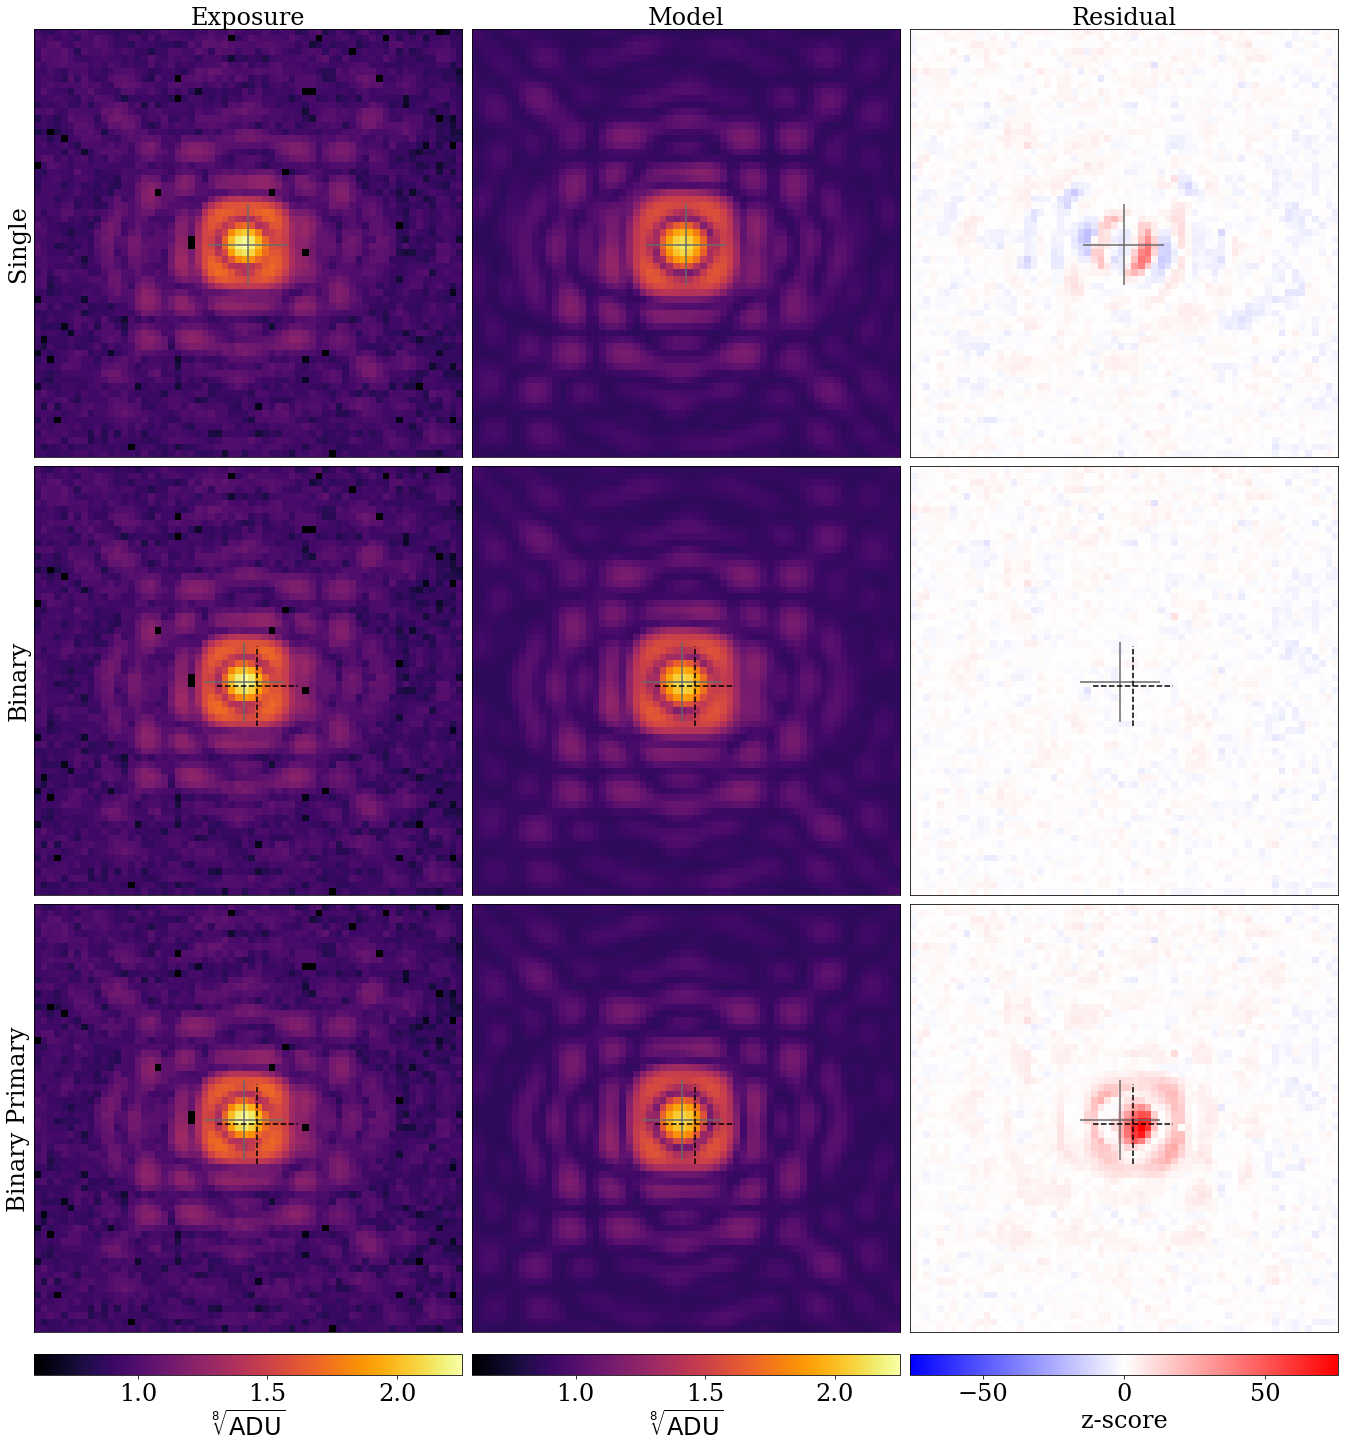

In [ ]:
fig, axs = plt.subplots(3,3, figsize = (20,20), layout='compressed')

ivm = 6e-1

cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)

coords = dlu.pixel_coords(512, 2.4)
cropped_frame = exp.data**0.125

binary_positions = dlu.rad2arcsec(dlu.positions_from_sep(
        dlu.arcsec2rad(final_params_binary["positions"]["n8o101a1q"]*0.042),
        dlu.arcsec2rad(final_params_binary["separation"]*0.042),
        dlu.deg2rad(final_params_binary["position_angle"])
    ))/0.042


# bottom panels (for vmax reasons)
binary_primary_positions =binary_positions[0]

binary_primary_spectrum = final_params_binary["primary_spectrum"]["GL164_F190N"]

print(binary_primary_positions)

bp_inject = {
    "positions": {"n8o101a1q":binary_primary_positions},
    "spectrum": {"GL164_F190N":binary_primary_spectrum},
    
}

bp_params = ModelParams({k: final_params_binary[k] for k in final_params_binary.params if k not in ["position_angle", "primary_spectrum", "secondary_spectrum", "separation"]} | bp_inject)

exp = exposures_single_f190N[0]
cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)


model = bp_params.inject(model_single)

fit = exp.fit(model, exp)

wid = fit.shape[0]

telescope_frame = fit**0.125

vm = max(np.nanmax(cropped_frame),np.nanmax(telescope_frame))
cd=axs[2, 0].imshow(cropped_frame, vmin=ivm,vmax=vm,cmap=cmap)
plt.colorbar(cd,ax=axs[2,0], orientation="horizontal", label=r"$\sqrt[8]{\text{ADU}}$")

tl=axs[2, 1].imshow(telescope_frame, vmin=ivm, vmax=vm,cmap=cmap)
plt.colorbar(tl,ax=axs[2,1], orientation="horizontal", label=r"$\sqrt[8]{\text{ADU}}$")


cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


resid = (exp.data - fit)/exp.err        
print(np.nanstd(resid))
rlim = np.nanmax(np.abs(resid))
residual=axs[2,2].imshow(resid, cmap='bwr',vmin=-rlim, vmax=rlim)
plt.colorbar(residual,ax=axs[2,2], orientation="horizontal", label="z-score")




# top panel

cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)



exp = exposures_single_f190N[0]


model = final_params_single.inject(model_single)

fit = exp.fit(model, exp)

wid = fit.shape[0]

telescope_frame = fit**0.125

vm = max(np.nanmax(cropped_frame),np.nanmax(telescope_frame))
cd=axs[0, 0].imshow(cropped_frame, vmin=ivm,vmax=vm,cmap=cmap)

tl=axs[0, 1].imshow(telescope_frame, vmin=ivm, vmax=vm,cmap=cmap)

cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


resid = (exp.data - fit)/exp.err        
print(np.nanstd(resid))
#rlim = np.nanmax(np.abs(resid))
residual=axs[0,2].imshow(resid, cmap='bwr',vmin=-rlim, vmax=rlim)
#plt.colorbar(residual,ax=axs[0,2])

cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)


# middle


exp = exposures_binary[0]

model = final_params_binary.inject(model_binary)

fit = exp.fit(model, exp)

wid = fit.shape[0]

telescope_frame = fit**0.125

vm = max(np.nanmax(cropped_frame),np.nanmax(telescope_frame))
cd=axs[1, 0].imshow(cropped_frame, vmin=ivm,vmax=vm,cmap=cmap)

tl=axs[1, 1].imshow(telescope_frame, vmin=ivm, vmax=vm,cmap=cmap)

cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


resid = (exp.data - fit)/exp.err        
print(np.nanstd(resid))
#rlim = np.nanmax(np.abs(resid))
residual=axs[1,2].imshow(resid, cmap='bwr',vmin=-rlim, vmax=rlim)
#plt.colorbar(residual,ax=axs[1,2])

#def param_replace(pa)




axs[0,0].xaxis.set_label_position('top')
axs[0,0].set_xlabel("Exposure")

axs[0,1].xaxis.set_label_position('top')
axs[0,1].set_xlabel("Model")

axs[0,2].xaxis.set_label_position('top')
axs[0,2].set_xlabel("Residual")

axs[0,0].set_ylabel("Single")
axs[1,0].set_ylabel("Binary")
axs[2,0].set_ylabel("Binary Primary")


#fig.tight_layout()

gx = 6


for i in range(1,3):
    for j in range(3):
        yp = float((wid)/2 - 0.25 - binary_positions[0,0])
        xp = float((wid)/2 - 0.25 - binary_positions[0,1])
        w = wid-1

        axs[i,j].vlines(yp, color='dimgrey',linestyle='-', ymin=xp-gx, ymax=xp+gx)
        axs[i,j].hlines(xp, color='dimgrey',linestyle='-', xmin = yp-gx, xmax = yp+gx)


        yp = float((wid)/2 - 0.25 - binary_positions[1,0])
        xp = float((wid)/2 - 0.25 - binary_positions[1,1])
        w = wid-1

        axs[i,j].vlines(yp, color='black',linestyle='--', ymin=xp-gx, ymax=xp+gx)
        axs[i,j].hlines(xp, color='black',linestyle='--', xmin = yp-gx, xmax = yp+gx)


i = 0
for j in range(3):
    yp = float((wid)/2 - 0.25 - final_params_single["positions"]["n8o101a1q"][0])
    xp = float((wid)/2 - 0.25 - final_params_single["positions"]["n8o101a1q"][1])
    w = wid-1

    axs[i,j].vlines(yp, color='dimgrey',linestyle='-', ymin=xp-gx, ymax=xp+gx)
    axs[i,j].hlines(xp, color='dimgrey',linestyle='-', xmin = yp-gx, xmax = yp+gx)



for i in range(3):
    for j in range(3):

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])